In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import compress_pickle as pickle  
import mplhep as hep
import compress_pickle
import pickle
import gzip
hep.style.use("CMS")
from helpers import *
import matplotlib.lines as mlines
from cycler import cycler
plt.rcParams["axes.prop_cycle"] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [2]:
color_list = [color_dict['color'] for color_dict in plt.rcParams["axes.prop_cycle"]]

### Note: This notebook assumes the theta values used are in mrad when calculating eta and plotting theta!

In [3]:
# Format is (particle, input feature dimensions, output feature dimensions, eta_low, eta_high, high/low granularity, already_rotated, date, theta mask during training)
conditions = {
    ('neutron', '4D', '3D', 1.273, 5.7, 'high_granularity', False, "August 2025", True):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_extended_eta_correctedSF_etamask_nomaxtheta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2025_extended_eta/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'high_granularity', False, "August 2025", False):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_extended_eta_correctedSF_nomaxtheta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2025_extended_eta/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'low_granularity', False, "August 2025", True):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_lowgranularity_extended_eta_correctedSF_etamask_nomaxtheta_test/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2025_extended_eta/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'low_granularity', False, "August 2025", False):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_lowgranularity_extended_eta_correctedSF_nomaxtheta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2025_extended_eta/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/'
    },
}
default_entry = {
    'result_dir': 'No_File',
    'preprocessed_dir': 'No_Title',
}

In [4]:
def get_model_predictions(model_dict, model_parameters_dict):
    model_info = model_dict.get( (model_parameters_dict["particle"],
                             model_parameters_dict["input_features"],
                             model_parameters_dict["output_dimensions"],
                             model_parameters_dict["theta_low"],
                             model_parameters_dict["theta_high"],
                             model_parameters_dict["granularity"],
                             model_parameters_dict["already_rotated"],
                             model_parameters_dict["date"],
                             model_parameters_dict["theta_mask"]),
                           default_entry)
    path_to_result = model_info['result_dir']
    
    targets, predictions = {}, {}
    if path_to_result == 'No_File':
        print('File not found')
        return targets, predictions
    
    npz_unpacked = np.load(path_to_result+"/predictions_appended_test.npz") 

    predictions_unnormalized = npz_unpacked['outputs_scaled']
    targets_unnormalized = npz_unpacked['targets_scaled']
    
    if model_parameters_dict["output_dimensions"] == '3D':
        targets["energy"] = targets_unnormalized[:,0]
        targets["theta"] = targets_unnormalized[:,1]
        targets["phi"] = targets_unnormalized[:,2]

        predictions["energy"] = predictions_unnormalized[:,0]
        predictions["theta"] = predictions_unnormalized[:,1]
        predictions["phi"] = predictions_unnormalized[:,2]
    elif model_parameters_dict["output_dimensions"] == '2D':
        targets["energy"] = targets_unnormalized[:,0]
        targets["theta"] = targets_unnormalized[:,1]

        predictions["energy"] = predictions_unnormalized[:,0]
        predictions["theta"] = predictions_unnormalized[:,1]
    elif model_parameters_dict["output_dimensions"] == '1D':
        targets["energy"] = targets_unnormalized
        predictions["energy"] = predictions_unnormalized
    else:
        print("Output dimensions isn't 1D, 2D, or 3D")

    return targets, predictions

In [5]:
high_granularity_parameters = {
    "particle" : 'neutron',             # pi+,  pi0, neutron, gamma
    "input_features" : '4D',            # input features [4D, 2D, 1D]
    "output_dimensions" : '3D',                # '1D', '2D', '3D'
    "theta_low" : 1.273,                 # Minimum theta value
    "theta_high" : 5.7,                 # Maximum theta value
    "granularity" : "high_granularity",
    "already_rotated" : False,          # The data was rotated to the proton axis during preprocessing
    "date" :  "August 2025",
    "theta_mask": False,
}

low_granularity_parameters = {
    "particle" : 'neutron',             # pi+,  pi0, neutron, gamma
    "input_features" : '4D',            # input features [4D, 2D, 1D]
    "output_dimensions" : '3D',                # '1D', '2D', '3D'
    "theta_low" : 1.273,                 # Minimum theta value
    "theta_high" : 5.7,                 # Maximum theta value
    "granularity" : "low_granularity",
    "already_rotated" : False,          # The data was rotated to the proton axis during preprocessing
    "date" :  "August 2025",
    "theta_mask": False,
}
high_granularity_dict, low_granularity_dict = {}, {}
high_granularity_dict["targets"], high_granularity_dict["predictions"] = get_model_predictions(
    conditions,
    high_granularity_parameters
)

low_granularity_dict["targets"], low_granularity_dict["predictions"] = get_model_predictions(
    conditions,
    low_granularity_parameters
)

In [6]:
high_granularity_dict["energy_bins"] = np.unique(np.round(high_granularity_dict["targets"]["energy"]).astype(int))
low_granularity_dict["energy_bins"] = np.unique(np.round(low_granularity_dict["targets"]["energy"]).astype(int))

In [7]:
eta_bins = [(3.2, 3.4), (3.4,3.6), (3.6,3.8),(3.8, 4)]


In [8]:
def get_histograms(data_dict, model_parameters_dict, eta_bins):
    
    eta_truth_energies, eta_energy_resolutions, eta_energy_scales = [], [], []
    eta_theta_resolutions, eta_phi_resolutions = [], []
    
    if not model_parameters_dict["already_rotated"]:
        if model_parameters_dict["output_dimensions"] == '3D':
            truth_eta_rot = rotated_eta_from_theta_phi(data_dict["targets"]["theta"], data_dict["targets"]["phi"], angle_rad=0.025)
        elif model_parameters_dict["output_dimensions"] == '2D':
            raise ValueError("Need phi to rotate around Y. Run a 3D target or provide phi.")
        else:
            raise ValueError("Rotation requires angular targets.")

        
        for eta_range in eta_bins:
            eta_mask = (truth_eta_rot >= eta_range[0]) & (truth_eta_rot < eta_range[1])
            truth_energies, energy_resolutions, energy_scales, energy_leakage = get_resolutions(
                data_dict["predictions"]["energy"][eta_mask],
                data_dict["targets"]["energy"][eta_mask],
                data_dict["energy_bins"],
                nbins=50,
                data_name="energy",
                divide_by_genE=True,
                title=f"Energy 3D ({eta_range[0]}<η*<{eta_range[1]}), {model_parameters_dict['granularity']}"
            )

            eta_truth_energies.append(truth_energies)
            eta_energy_resolutions.append(energy_resolutions)
            eta_energy_scales.append(energy_scales)

            theta_predicted_truth_difference = data_dict["predictions"]["theta"][eta_mask] - data_dict["targets"]["theta"][eta_mask]
            _, theta_resolutions, _, _ = get_resolutions(theta_predicted_truth_difference,
                                                         data_dict["targets"]["energy"][eta_mask],
                                                         data_dict["energy_bins"],
                                                         nbins = 50,
                                                         data_name = "theta",
                                                         title=f"Theta 3D ({eta_range[0]}<η*<{eta_range[1]}), {model_parameters_dict['granularity']}")

            eta_theta_resolutions.append(theta_resolutions)

            phi_predicted_truth_difference = data_dict["predictions"]["phi"][eta_mask] - data_dict["targets"]["phi"][eta_mask]
            _, phi_resolutions, _, _ = get_resolutions(phi_predicted_truth_difference,
                                                       data_dict["targets"]["energy"][eta_mask],
                                                       data_dict["energy_bins"],
                                                       nbins = 50,
                                                       data_name = "phi",
                                                       title=f"Phi 3D ({eta_range[0]}<η*<{eta_range[1]}), {model_parameters_dict['granularity']}")

            eta_phi_resolutions.append(phi_resolutions)

    else:
        for eta_range in eta_bins:
            truth_eta = -np.log(np.tan(data_dict["targets"]["theta"]/1000/2))
            eta_mask = (truth_eta>=eta_range[0]) & (truth_eta<eta_range[1])
            truth_energies, energy_resolutions, energy_scales, energy_leakage = get_resolutions(
                data_dict["predictions"]["energy"][eta_mask],
                data_dict["targets"]["energy"][eta_mask],
                data_dict["energy_bins"],
                nbins=50,
                data_name="energy",
                divide_by_genE=True,
                title=f"Energy 3D ({eta_range[0]}<η*<{eta_range[1]}), {model_parameters_dict['granularity']}"
            )
            eta_truth_energies.append(truth_energies)
            eta_energy_resolutions.append(energy_resolutions)
            eta_energy_scales.append(energy_scales)

            theta_predicted_truth_difference = data_dict["predictions"]["theta"][eta_mask] - data_dict["targets"]["theta"][eta_mask]
            _, theta_resolutions, _, _ = get_resolutions(theta_predicted_truth_difference,
                                                         data_dict["targets"]["energy"][eta_mask],
                                                         data_dict["energy_bins"],
                                                         nbins = 50,
                                                         data_name = "theta",
                                                         title=f"Theta 3D ({eta_range[0]}<η*<{eta_range[1]}), {model_parameters_dict['granularity']}")

            eta_theta_resolutions.append(theta_resolutions)

            phi_predicted_truth_difference = data_dict["predictions"]["phi"][eta_mask] - data_dict["targets"]["phi"][eta_mask]
            _, phi_resolutions, _, _ = get_resolutions(phi_predicted_truth_difference,
                                                       data_dict["targets"]["energy"][eta_mask],
                                                       data_dict["energy_bins"],
                                                       nbins = 50,
                                                       data_name = "phi",
                                                       title=f"Phi 3D ({eta_range[0]}<η*<{eta_range[1]}), {model_parameters_dict['granularity']}")

            eta_phi_resolutions.append(phi_resolutions)
    output_dict = {
        "eta_truth_energies" : eta_truth_energies,
        "eta_energy_resolutions" : eta_energy_resolutions,
        "eta_energy_scales": eta_energy_scales,
        "eta_theta_resolutions": eta_theta_resolutions,
        "eta_phi_resolutions" : eta_phi_resolutions,
    }
    return output_dict

/home/ryan/insert_granularity_studies/src/notebooks/helpers.py:102: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axs = plt.subplots(row,col, figsize=(18, 15),sharex=False)


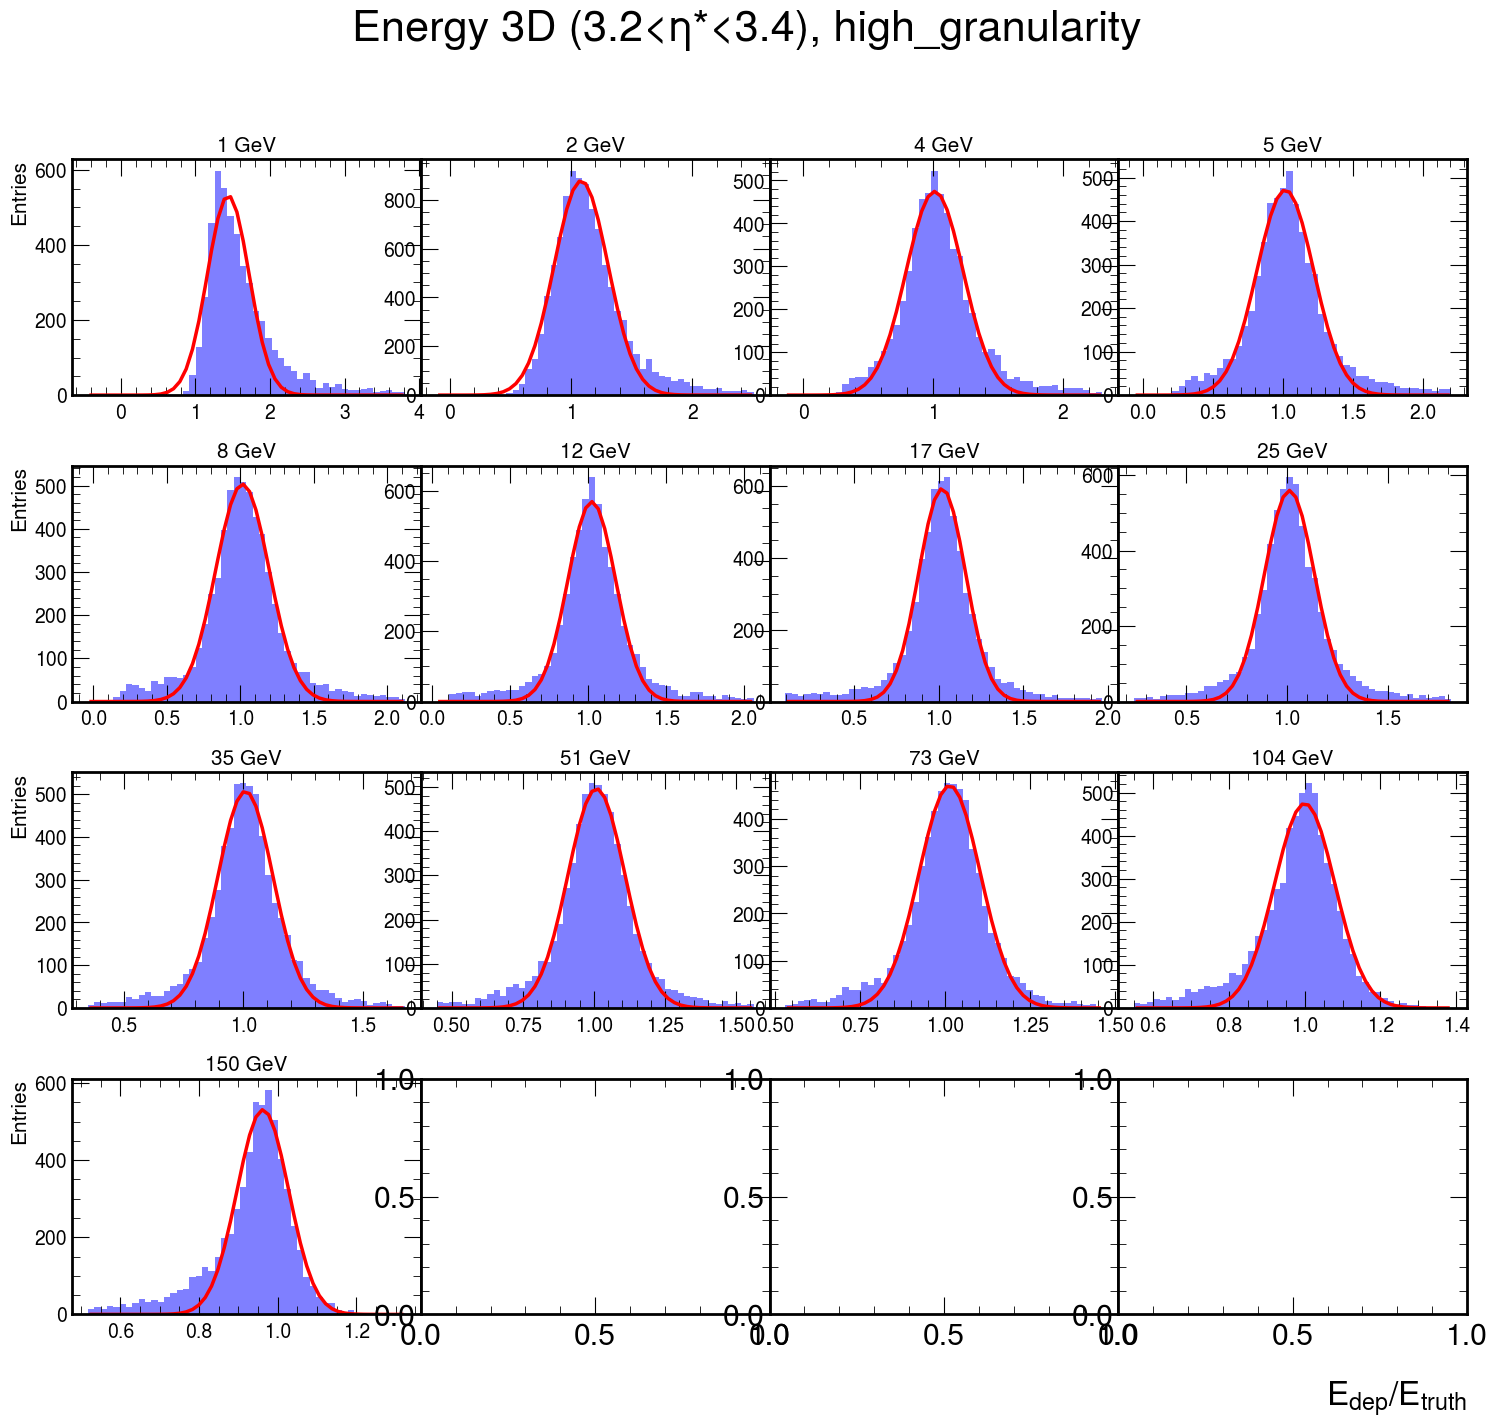

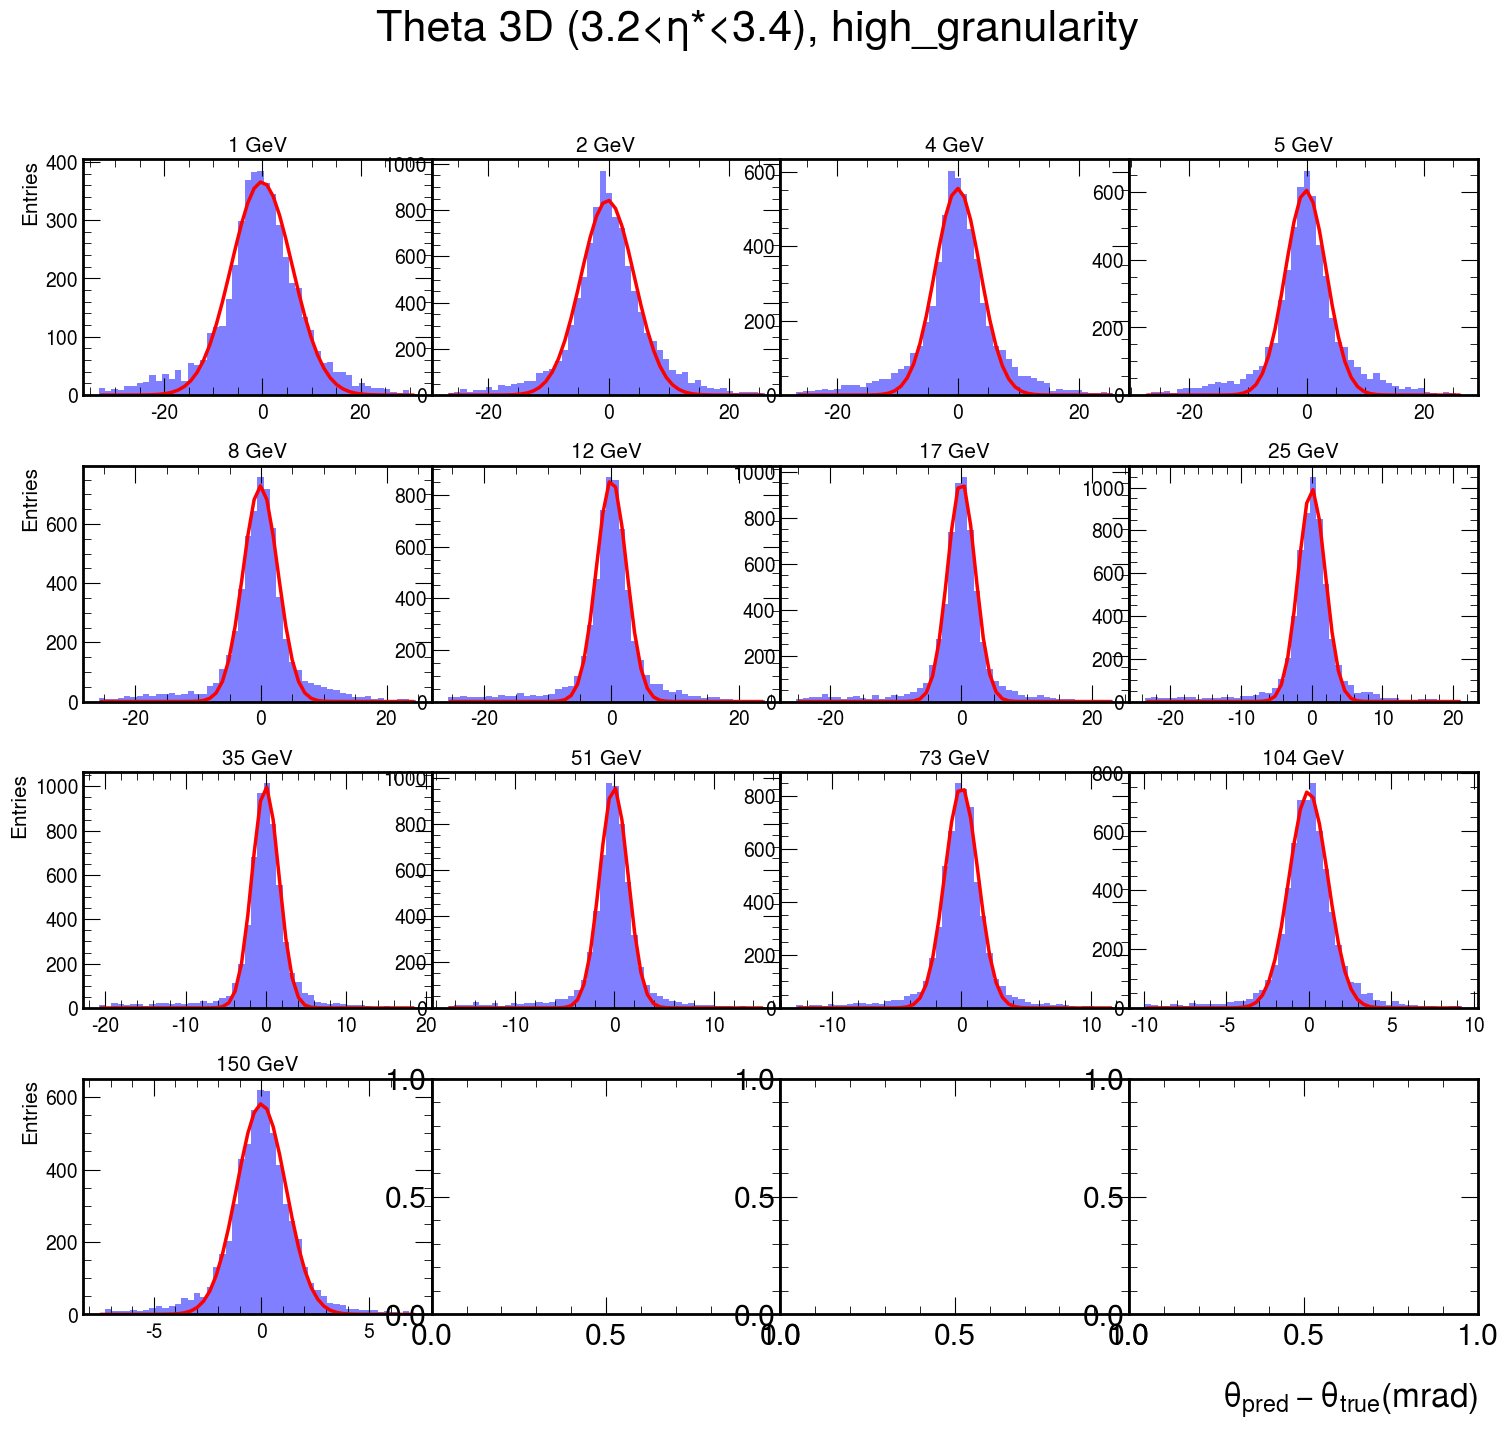

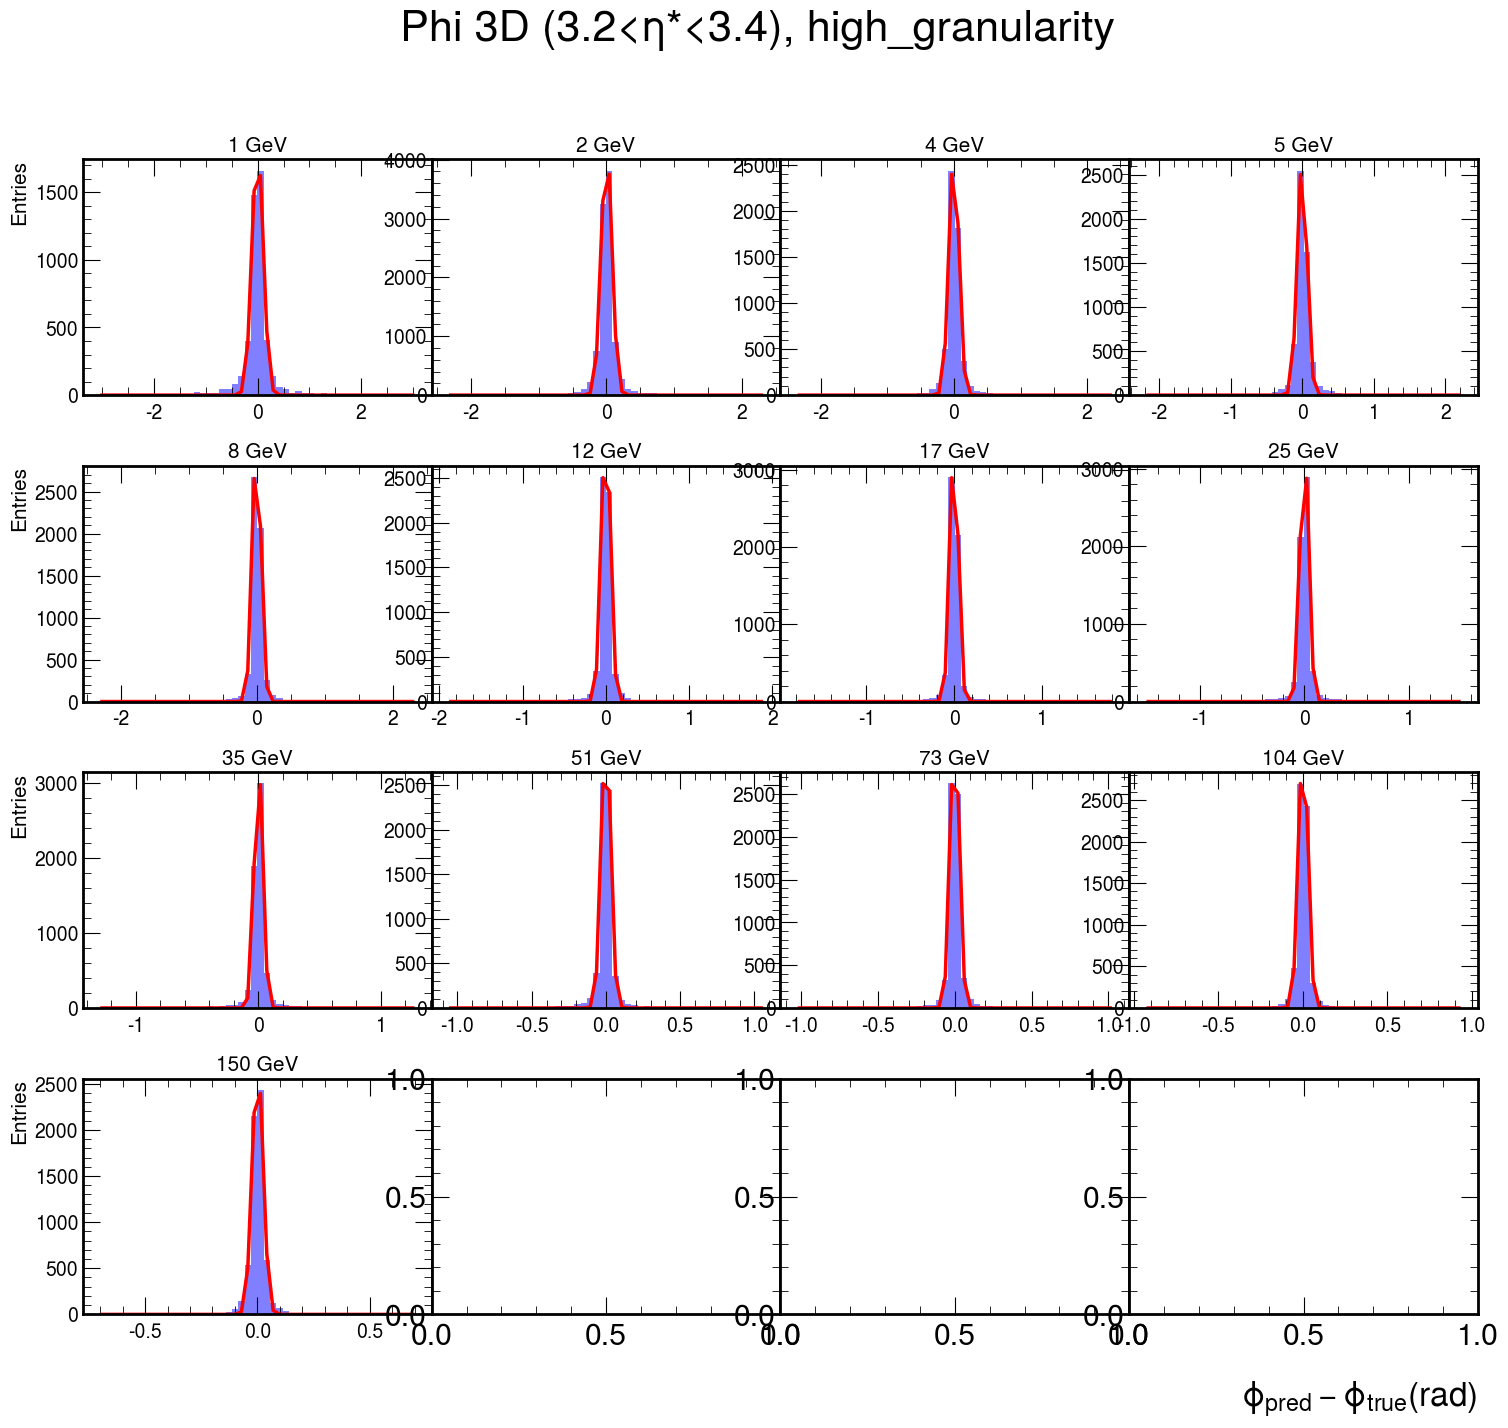

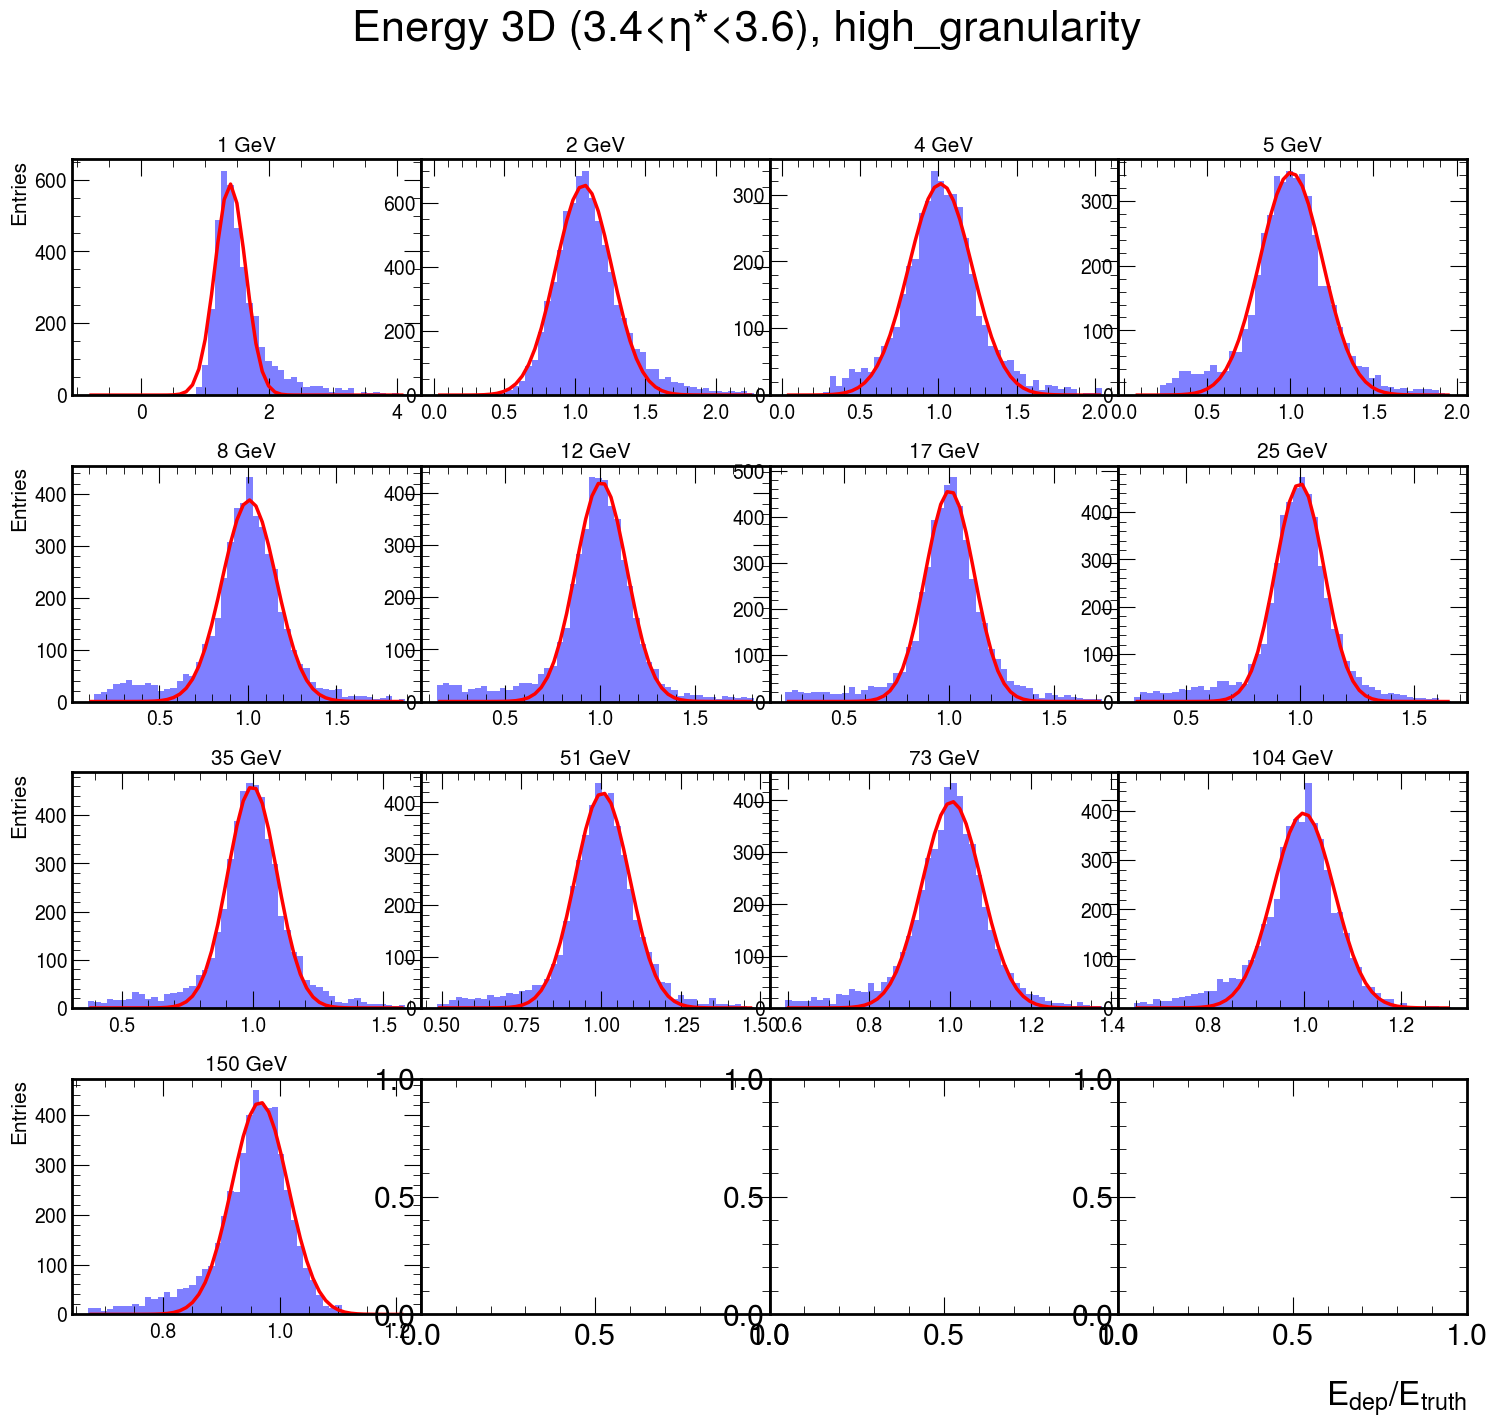

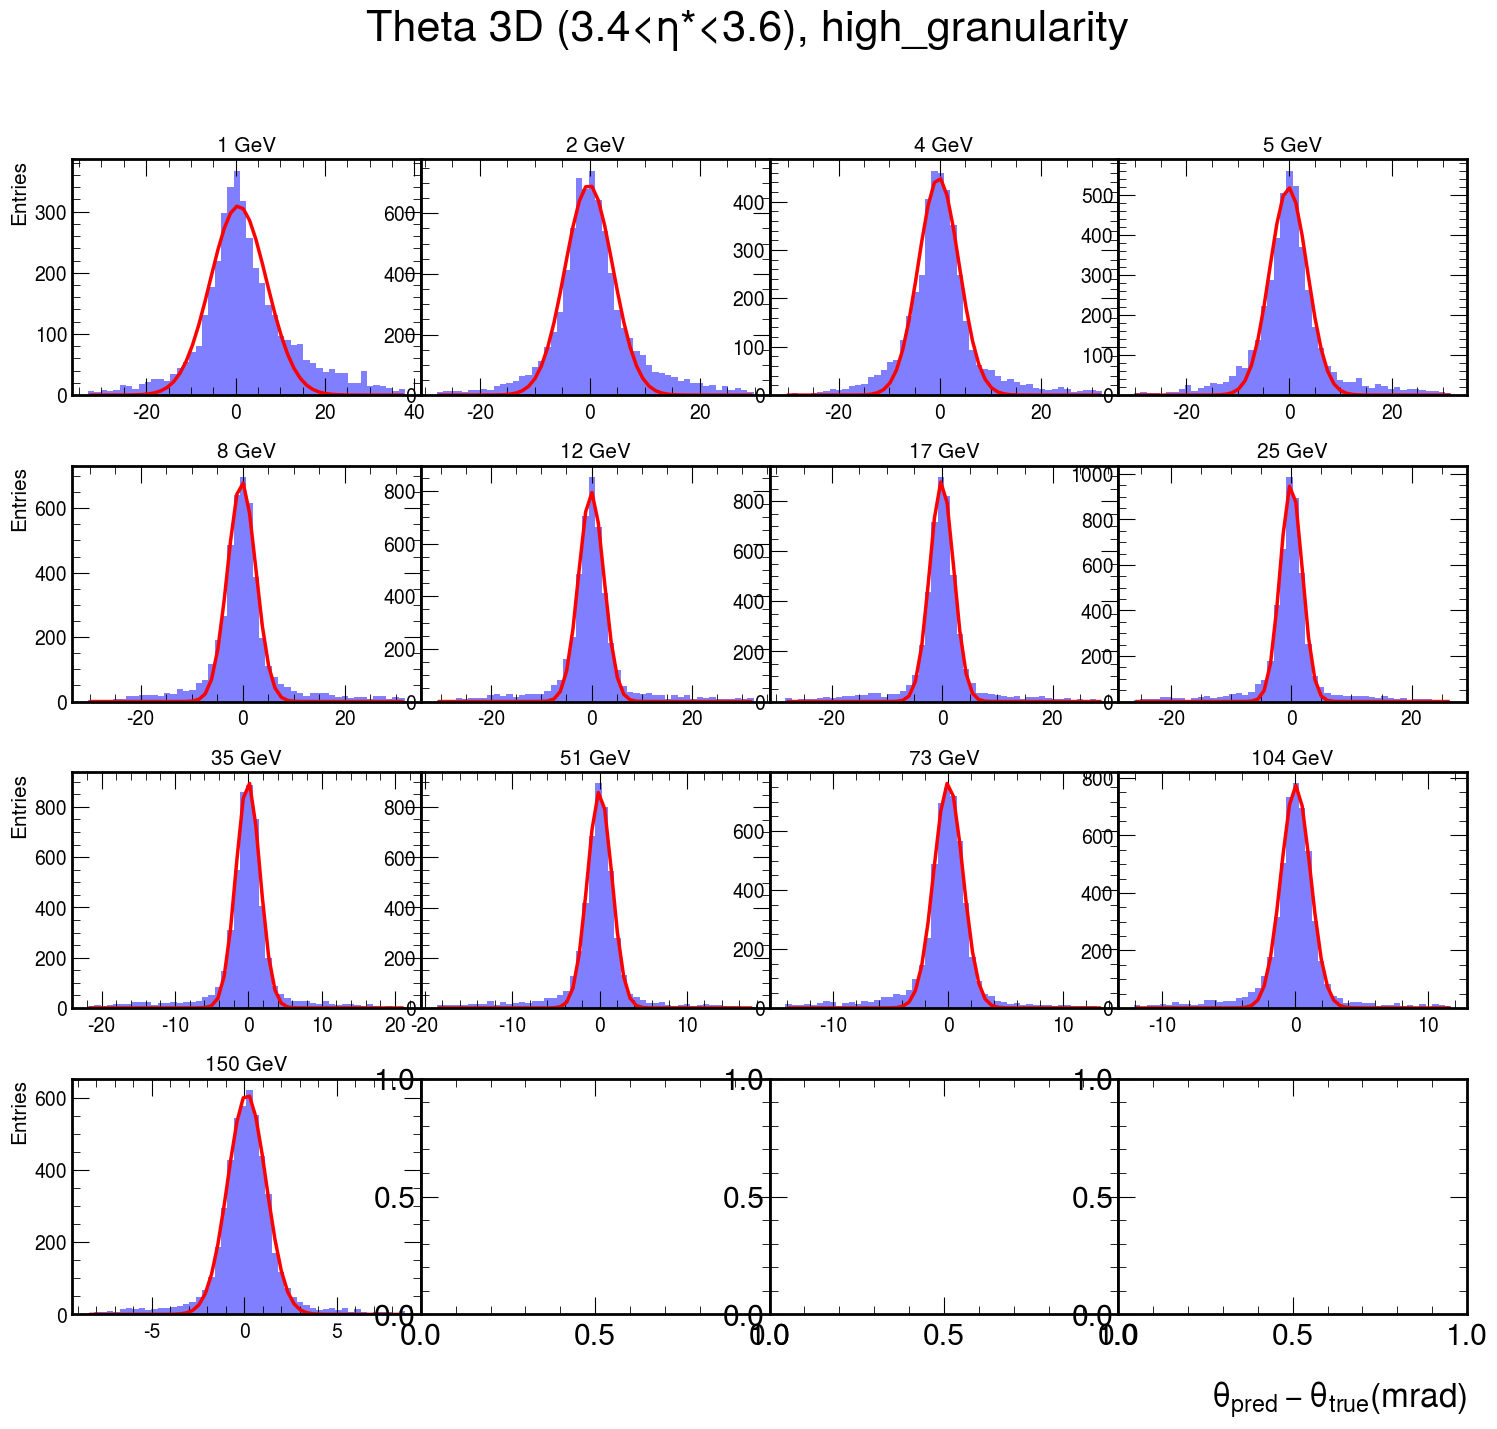

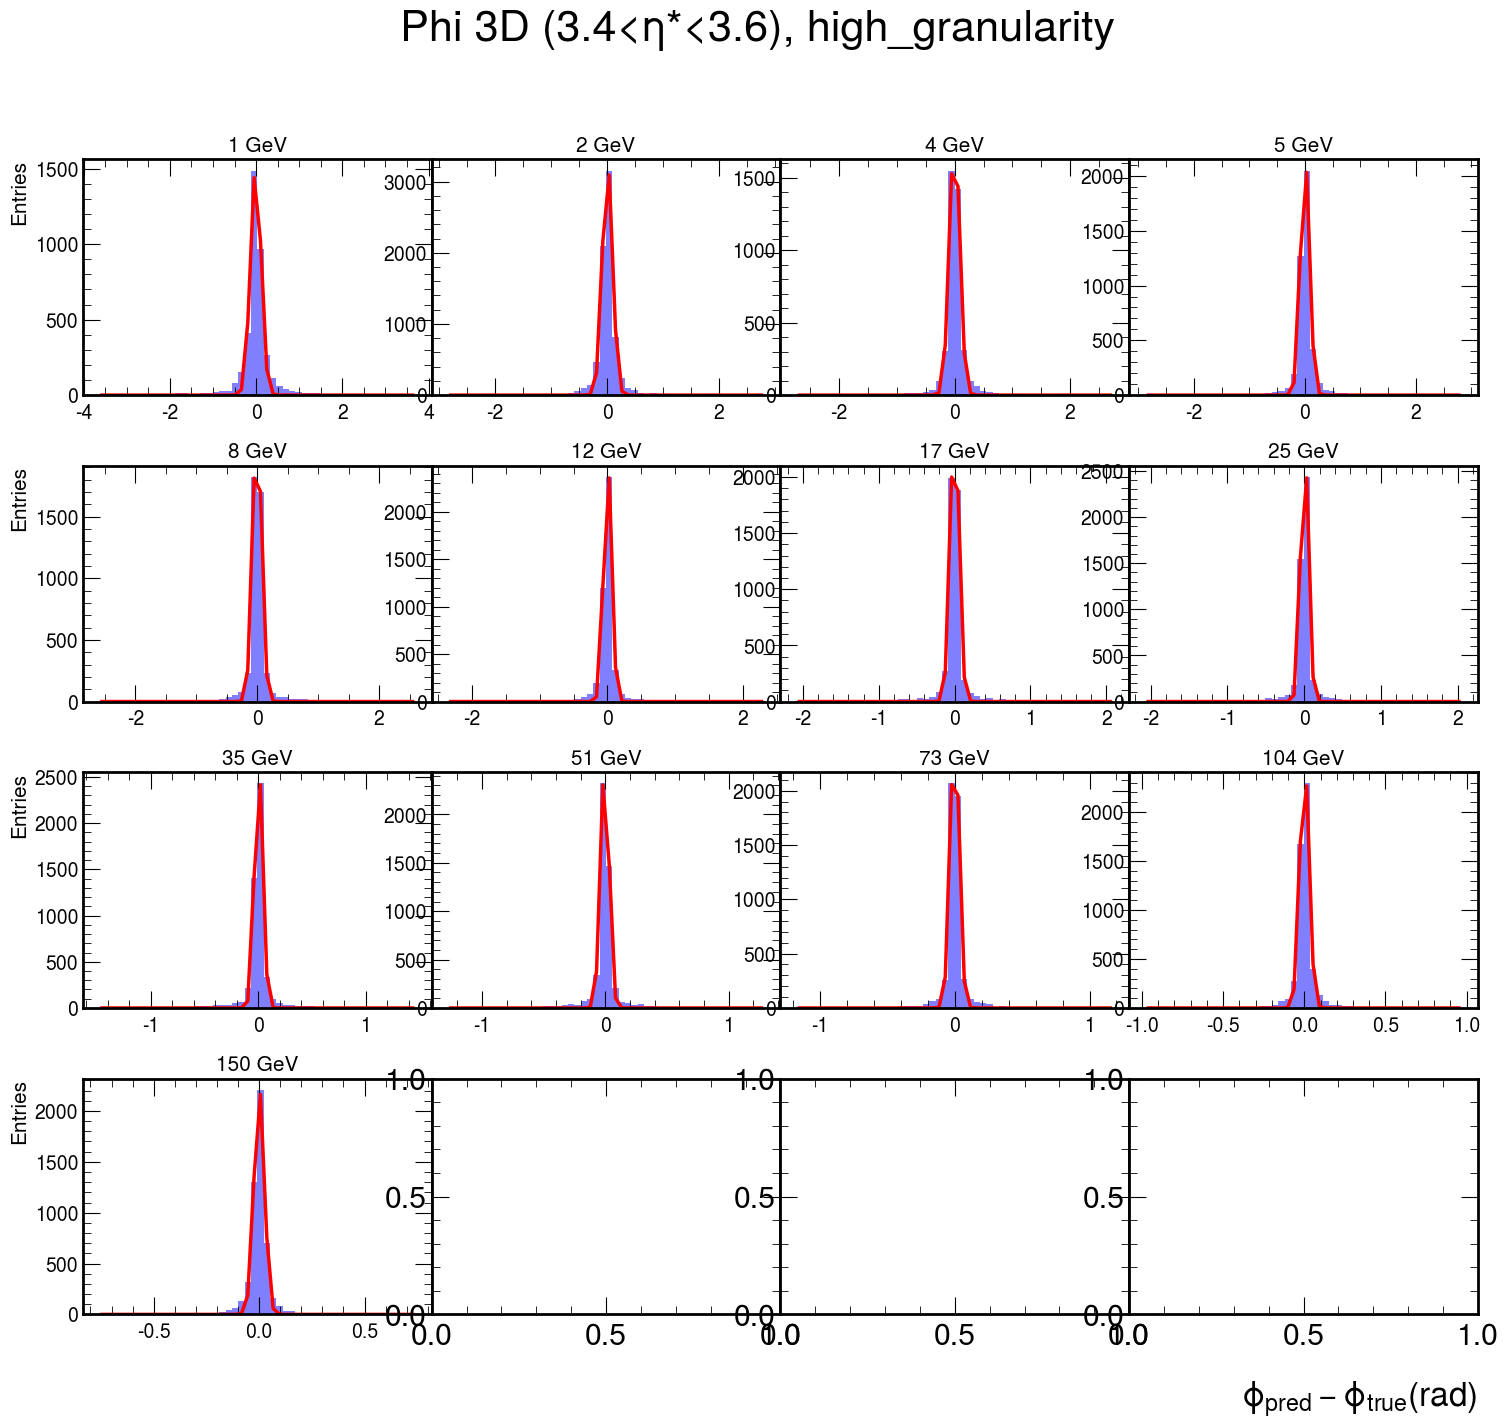

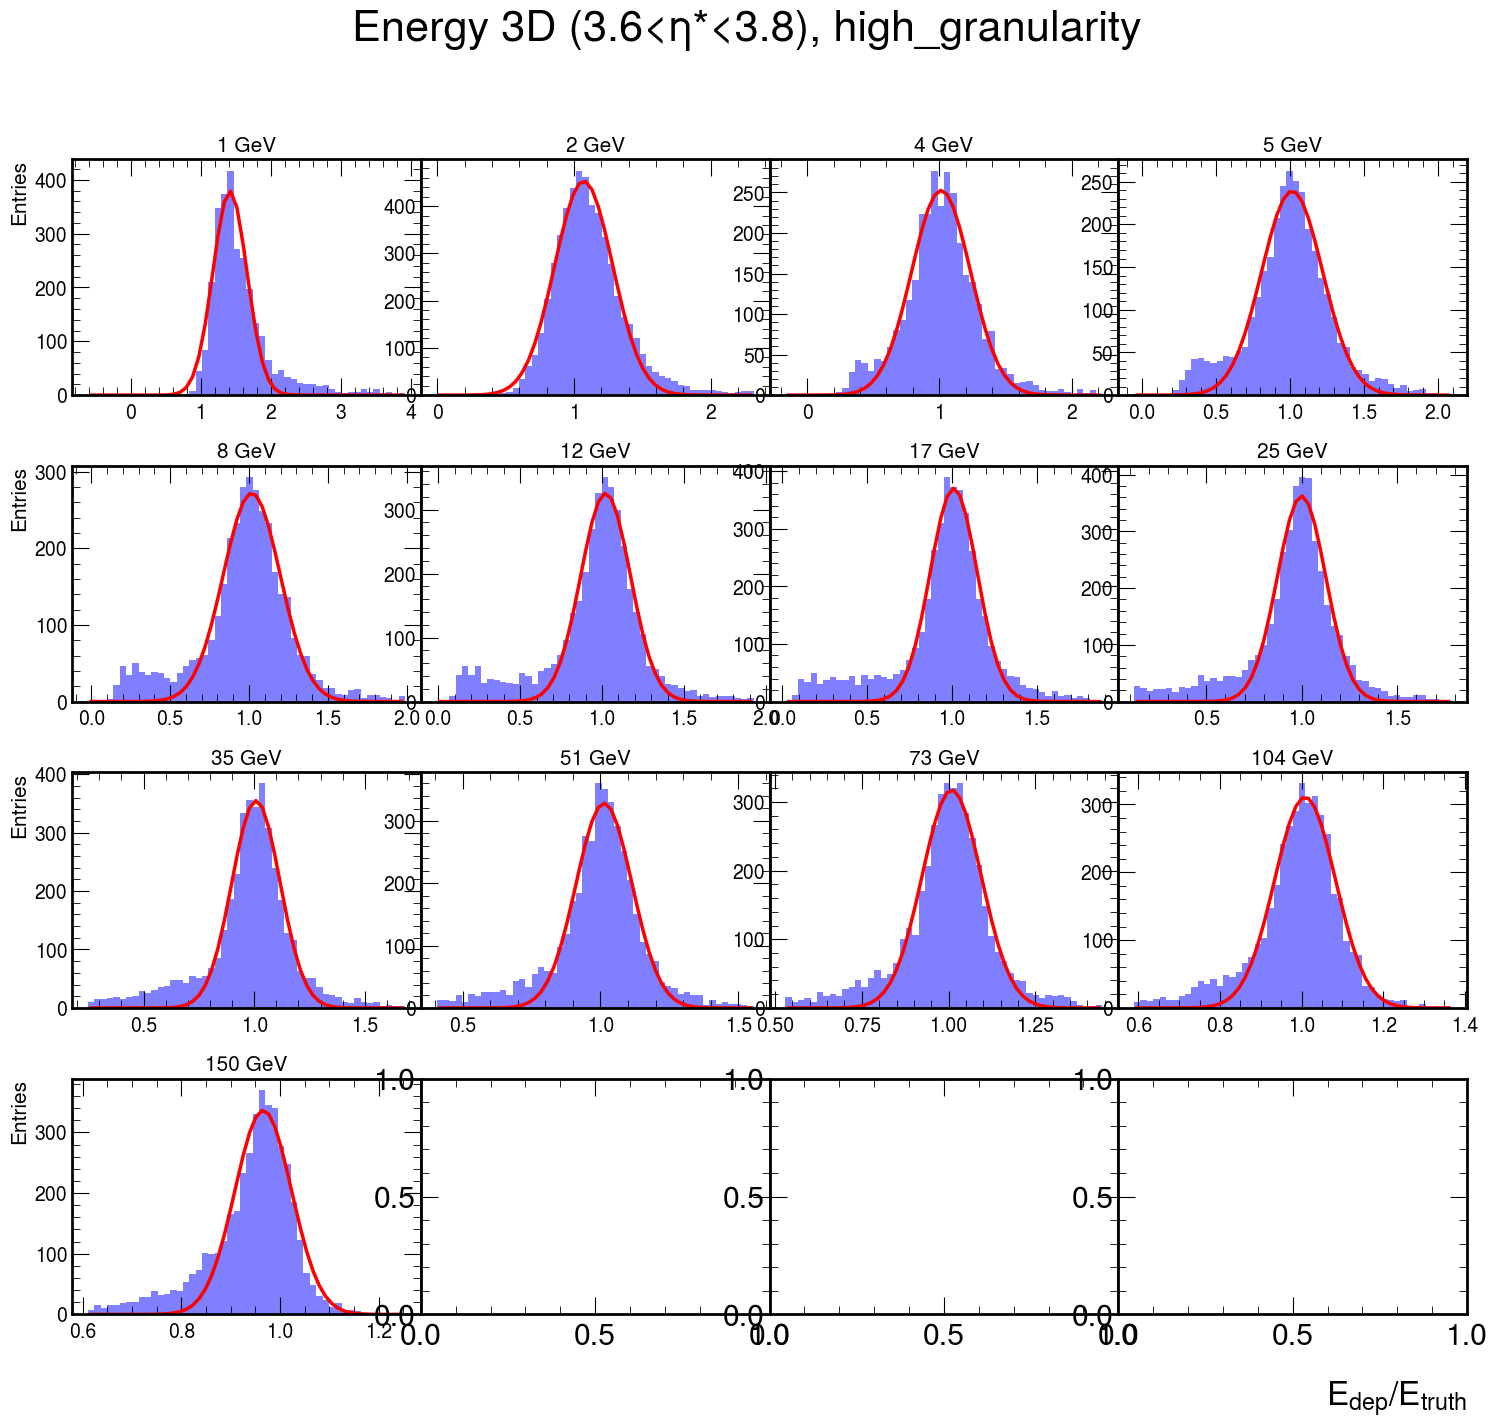

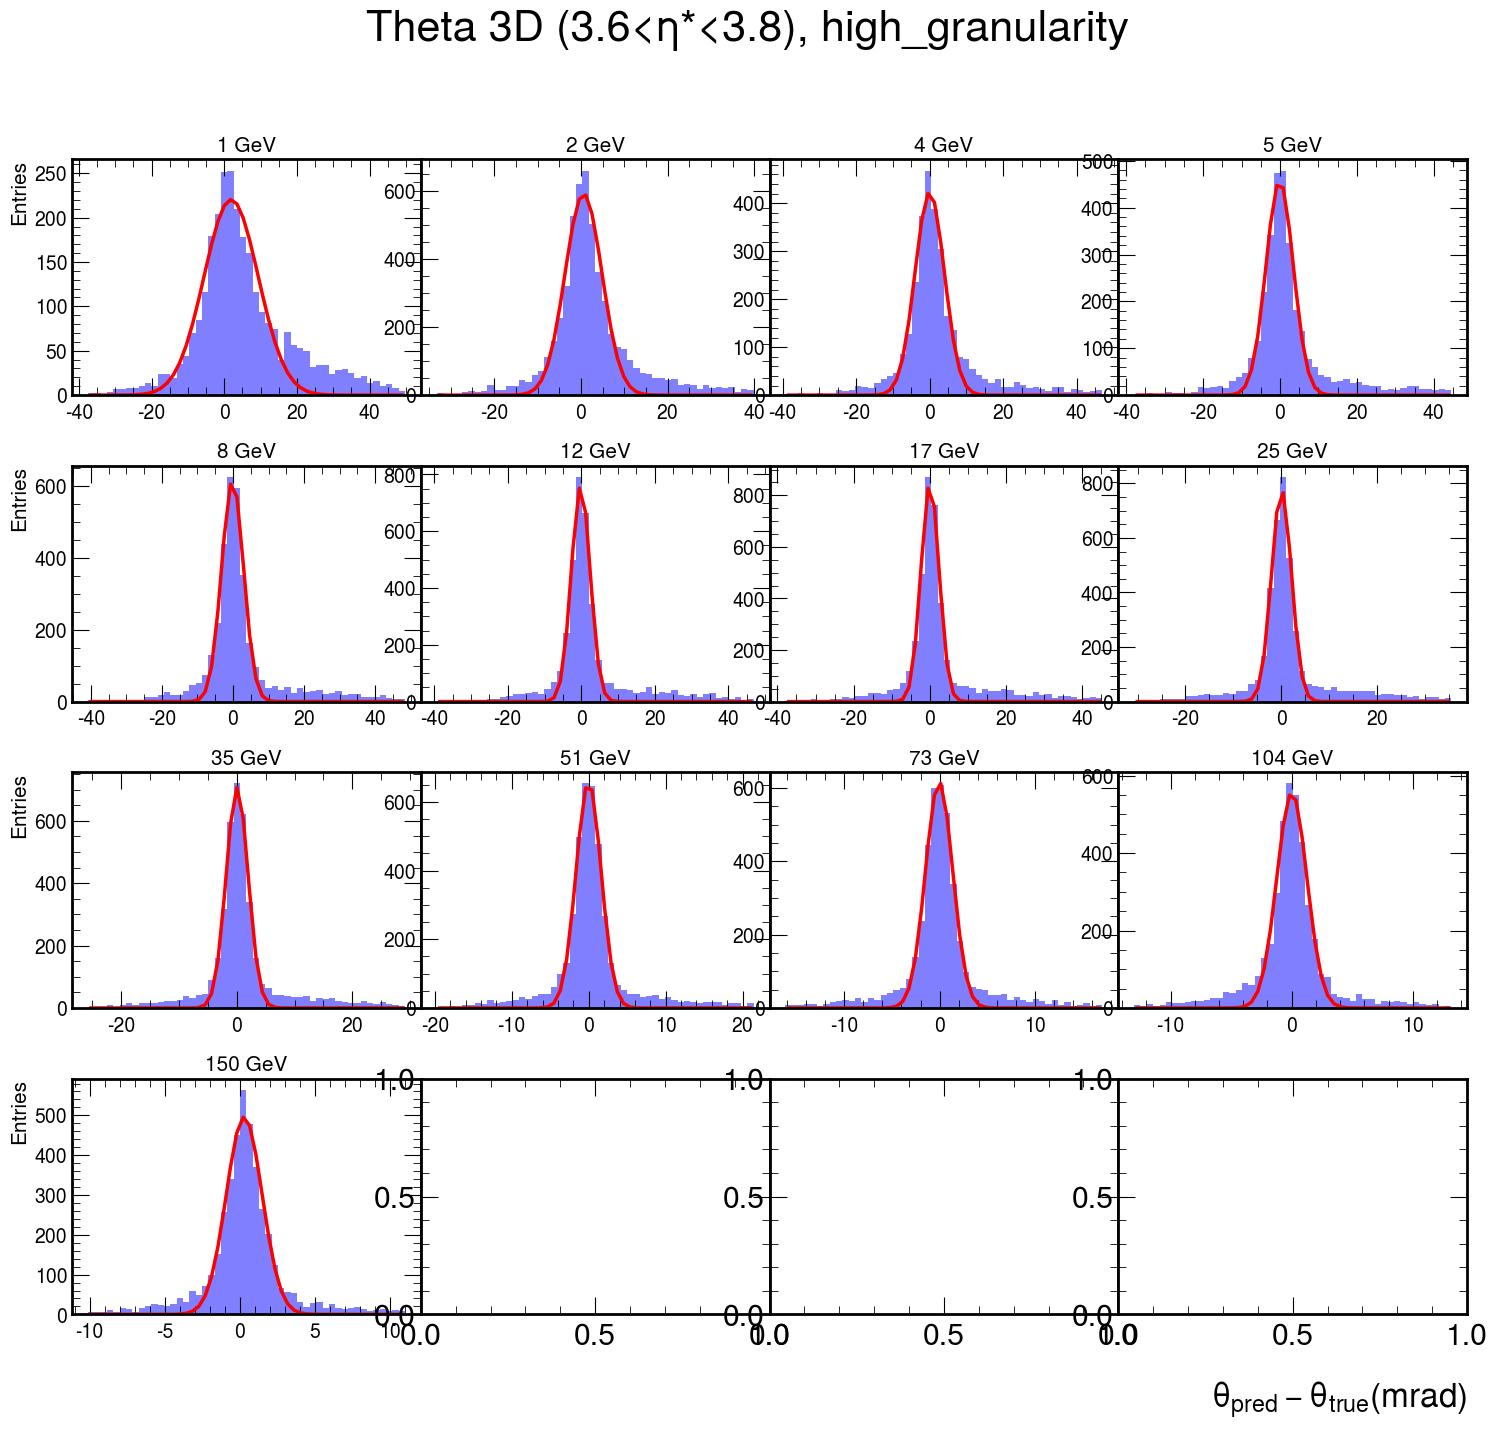

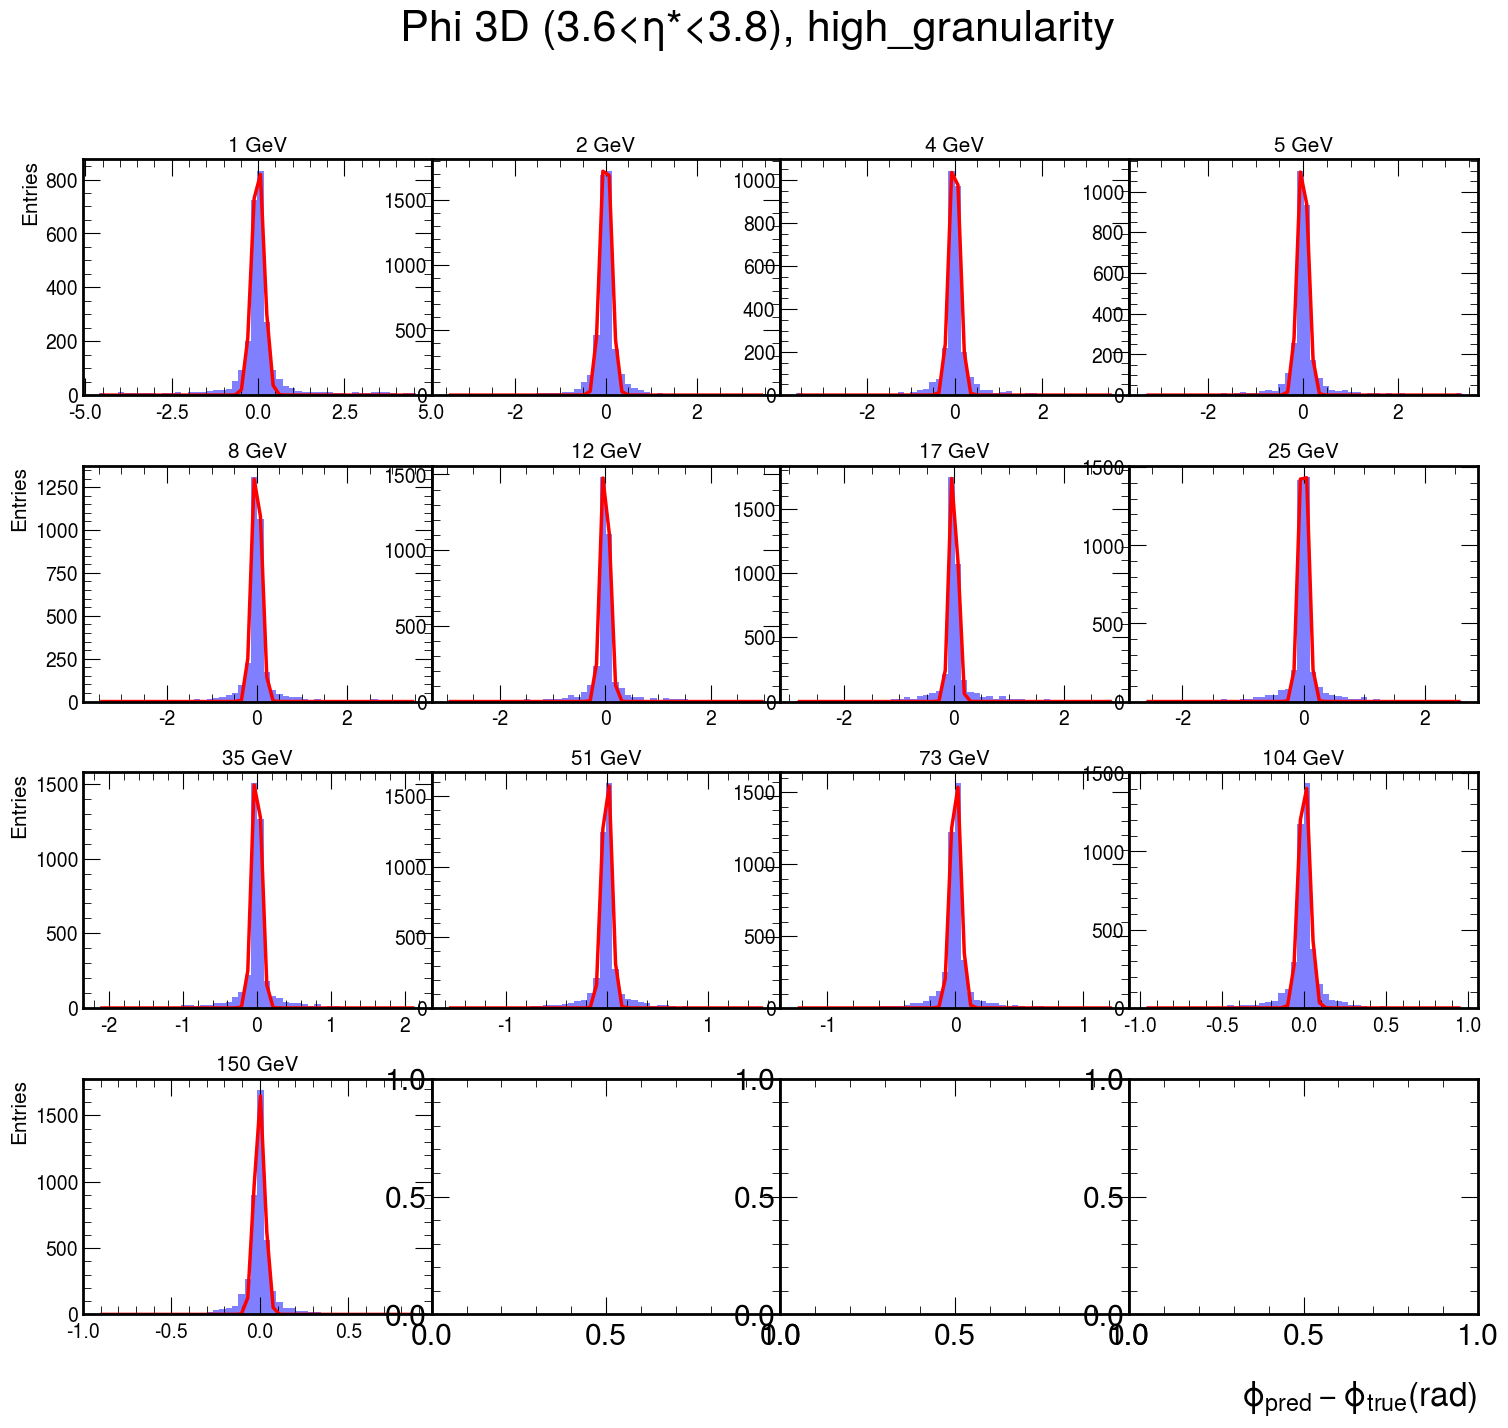

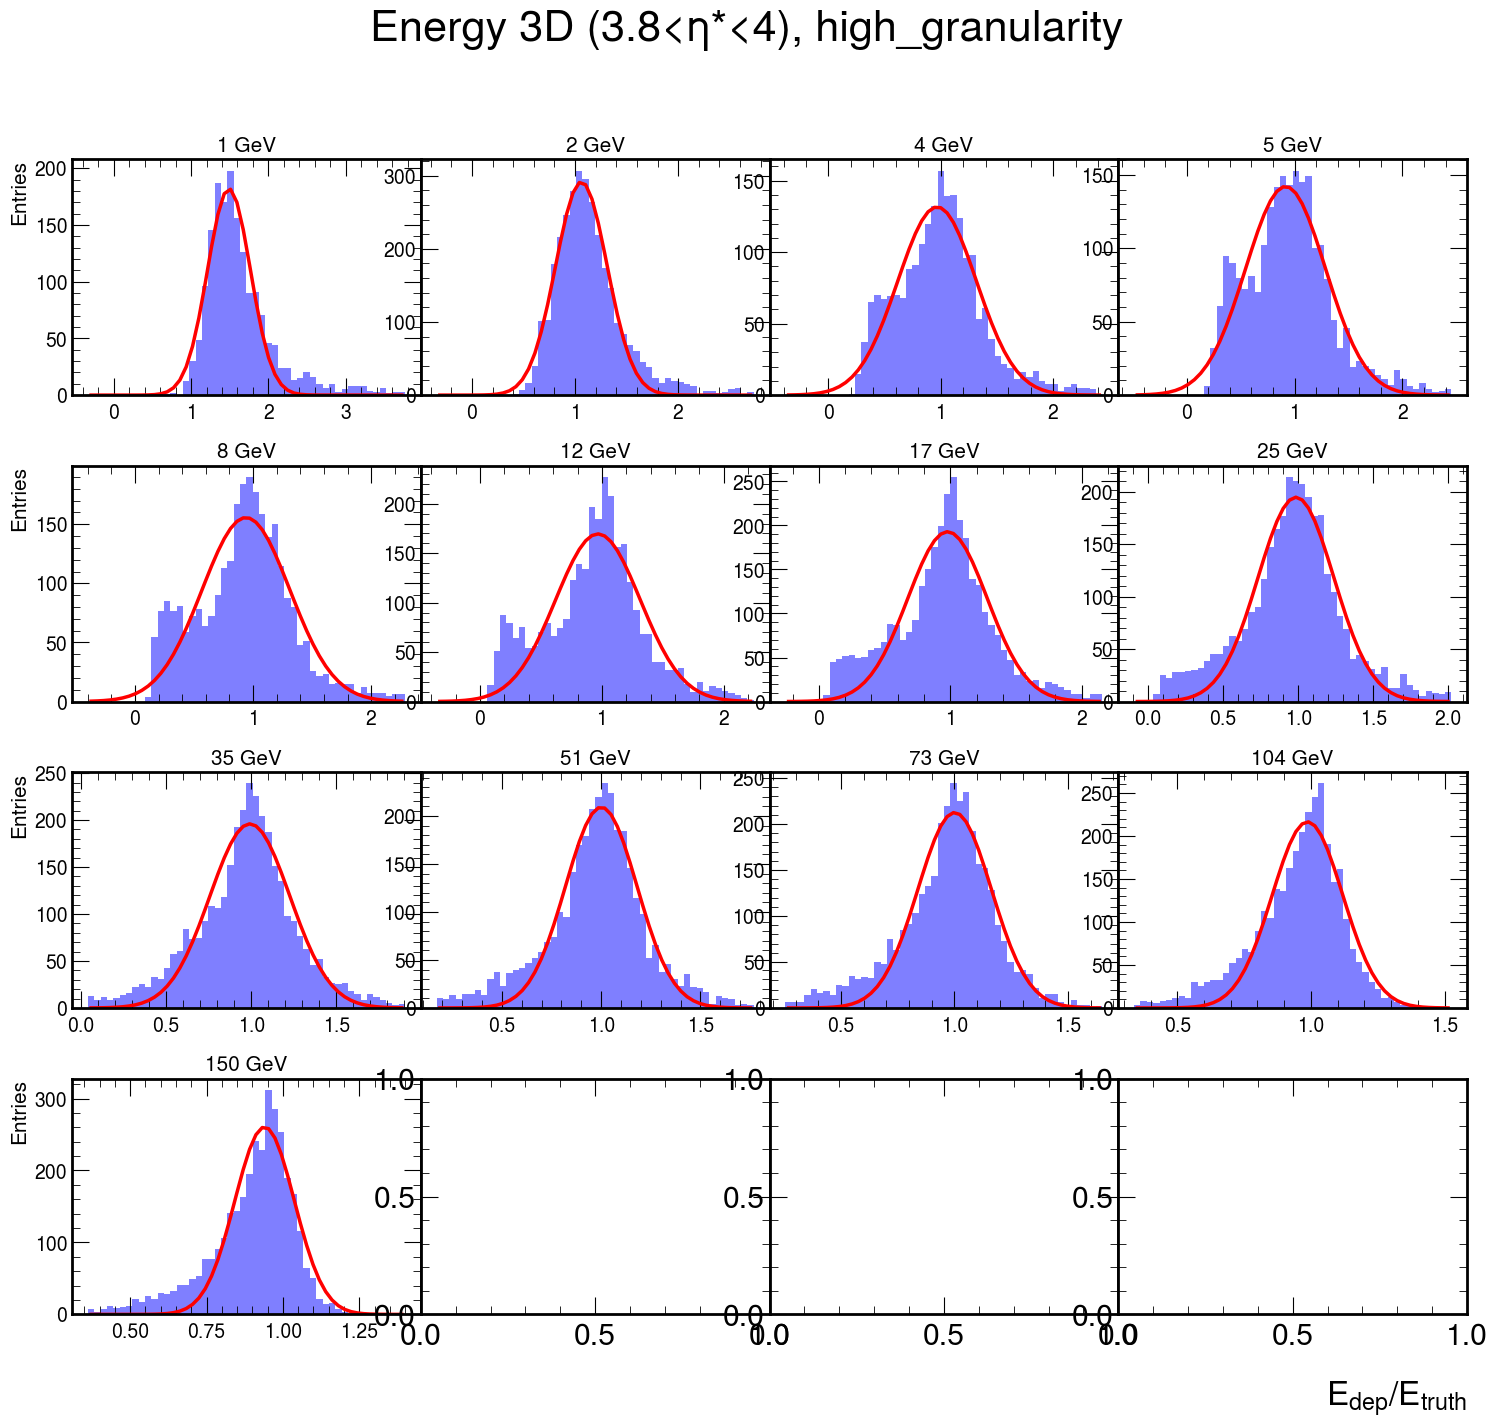

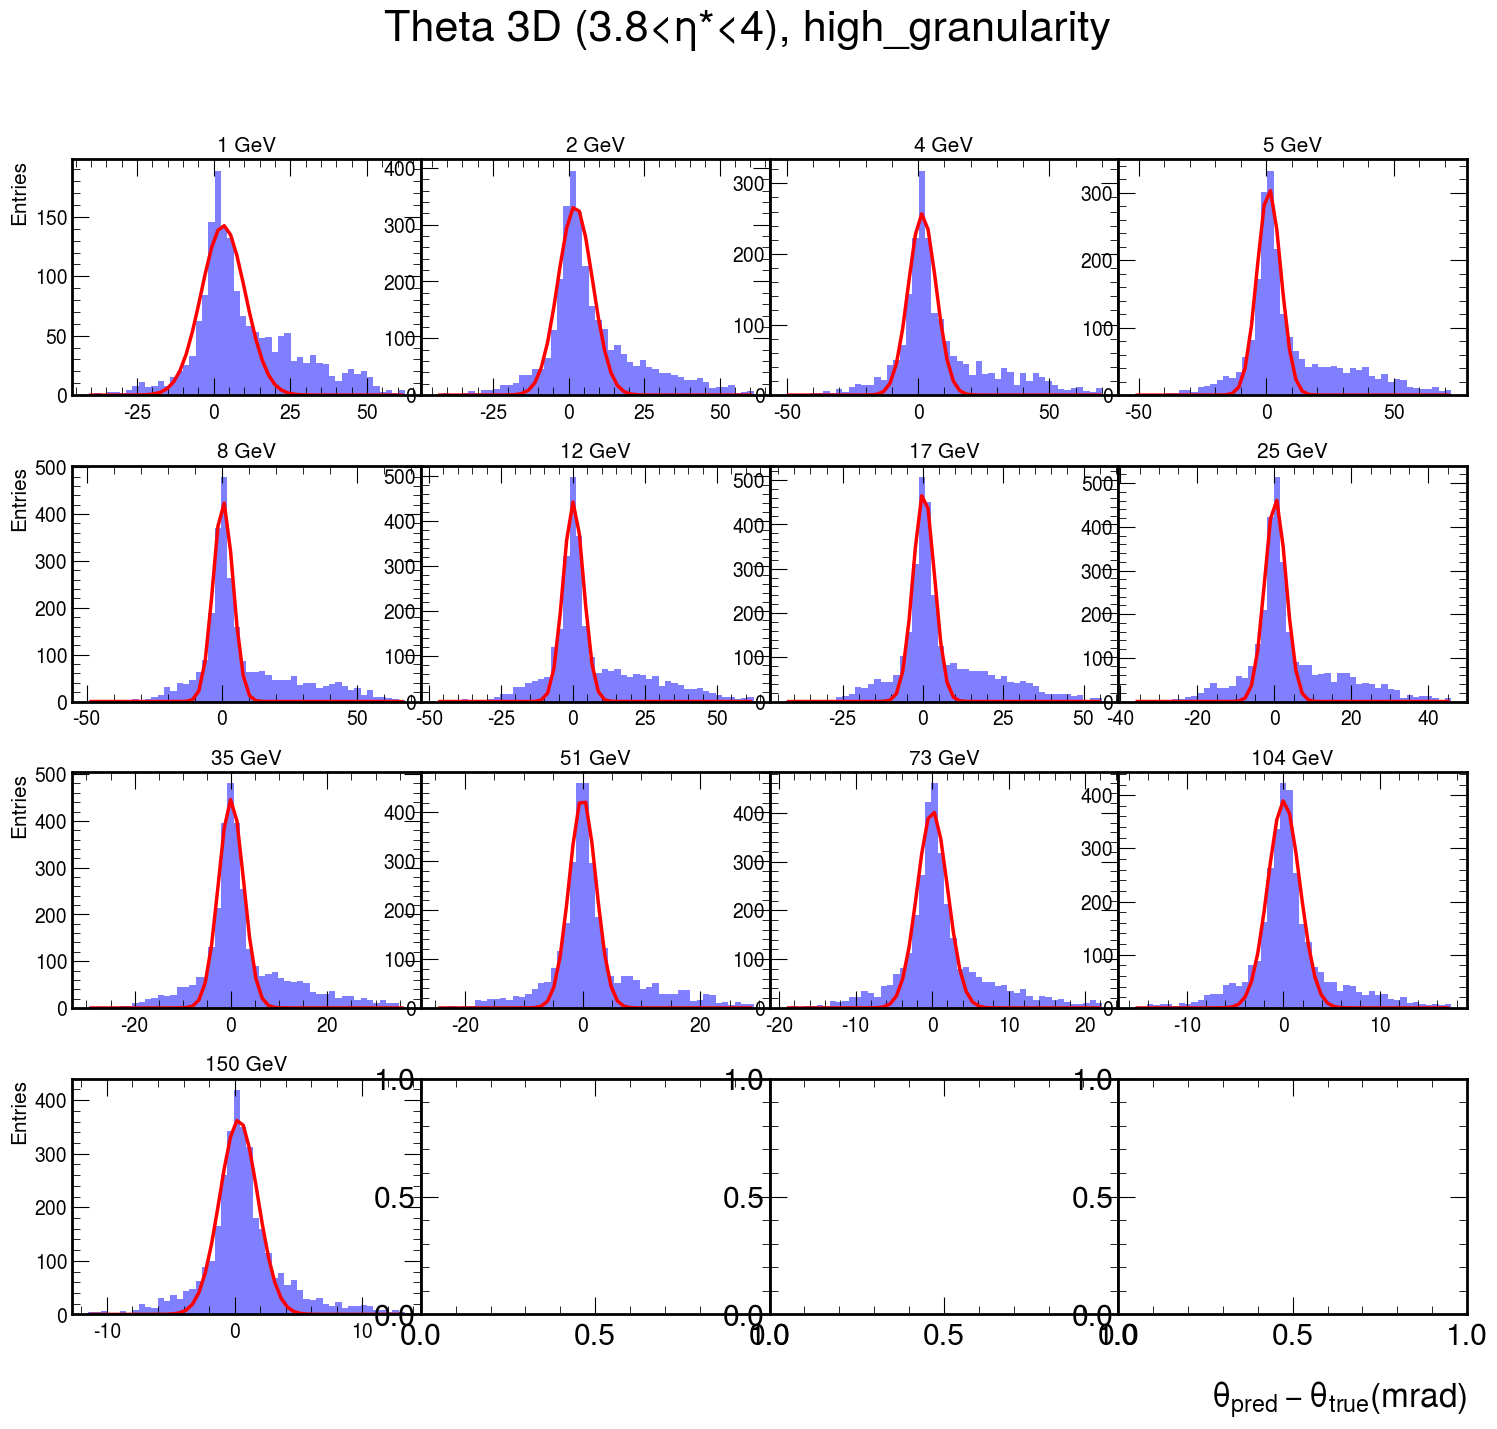

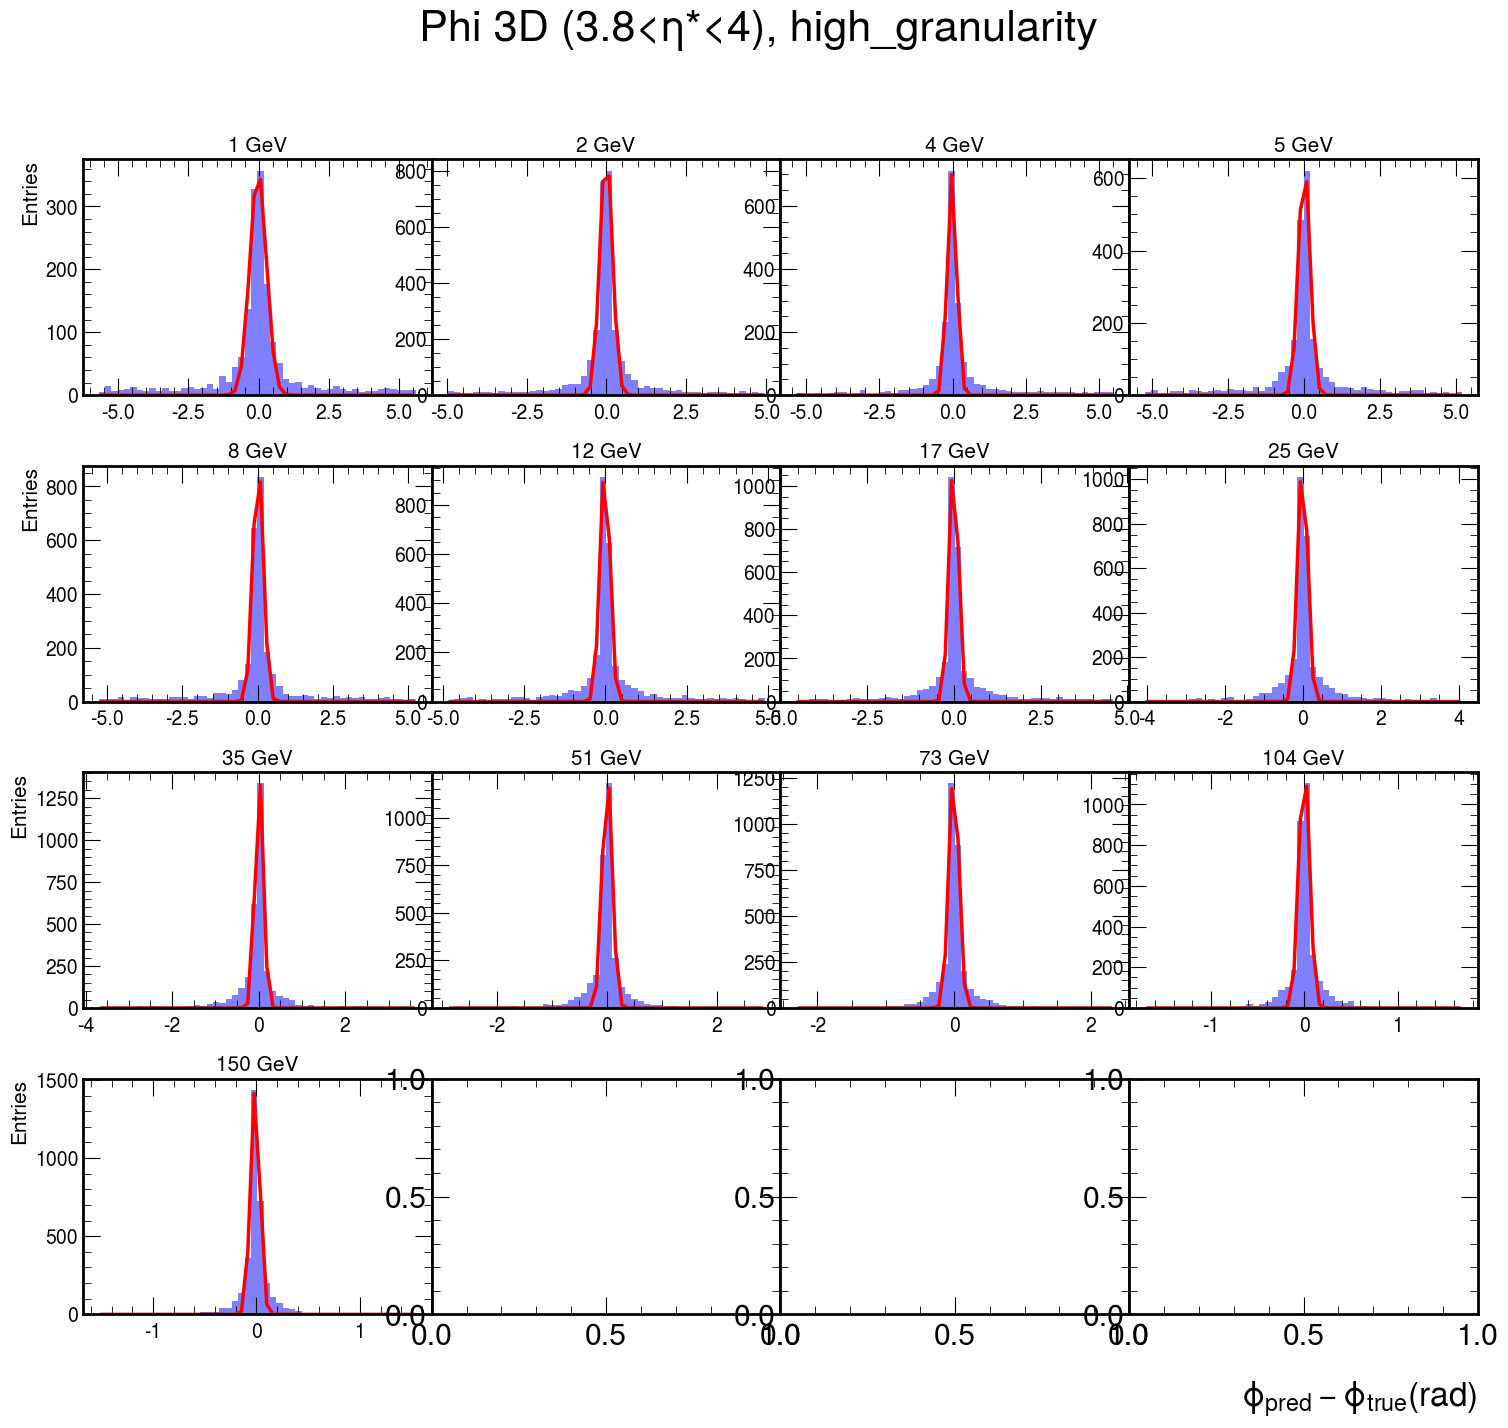

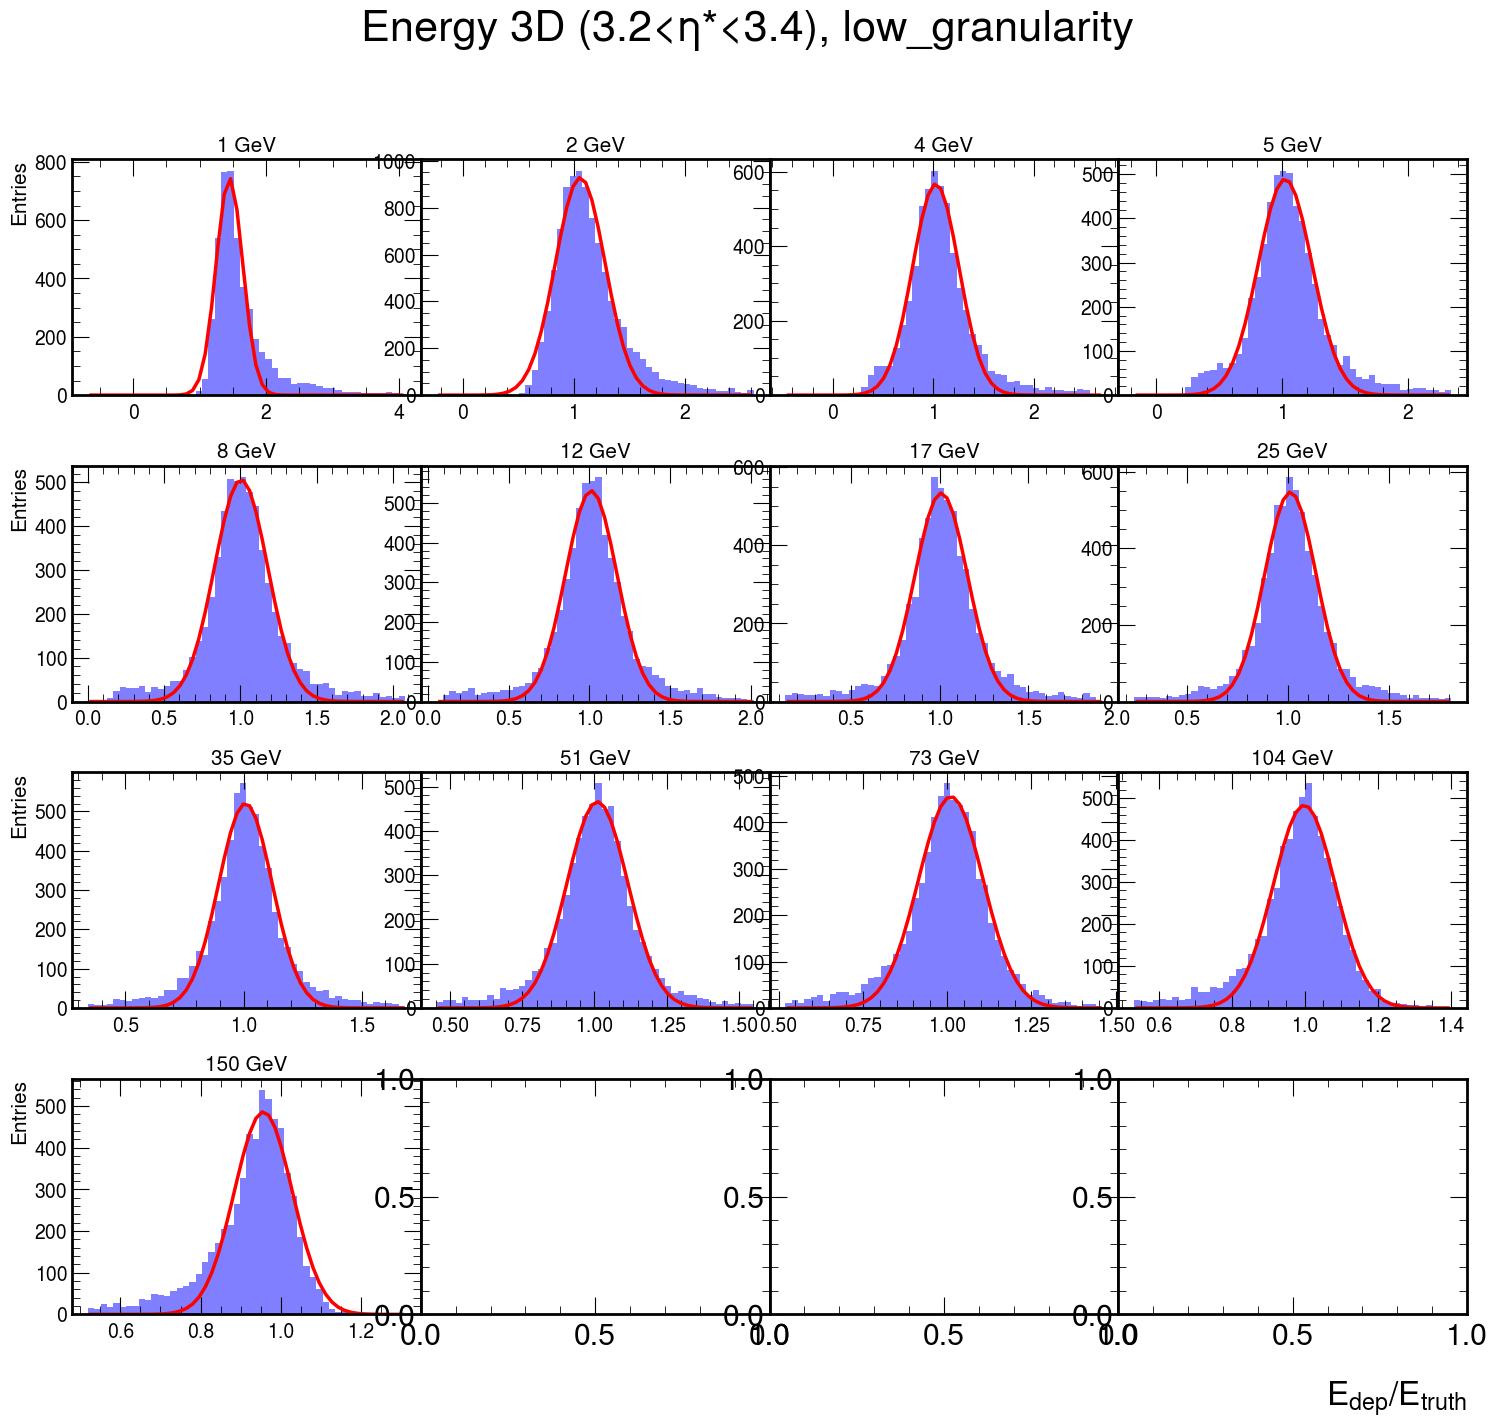

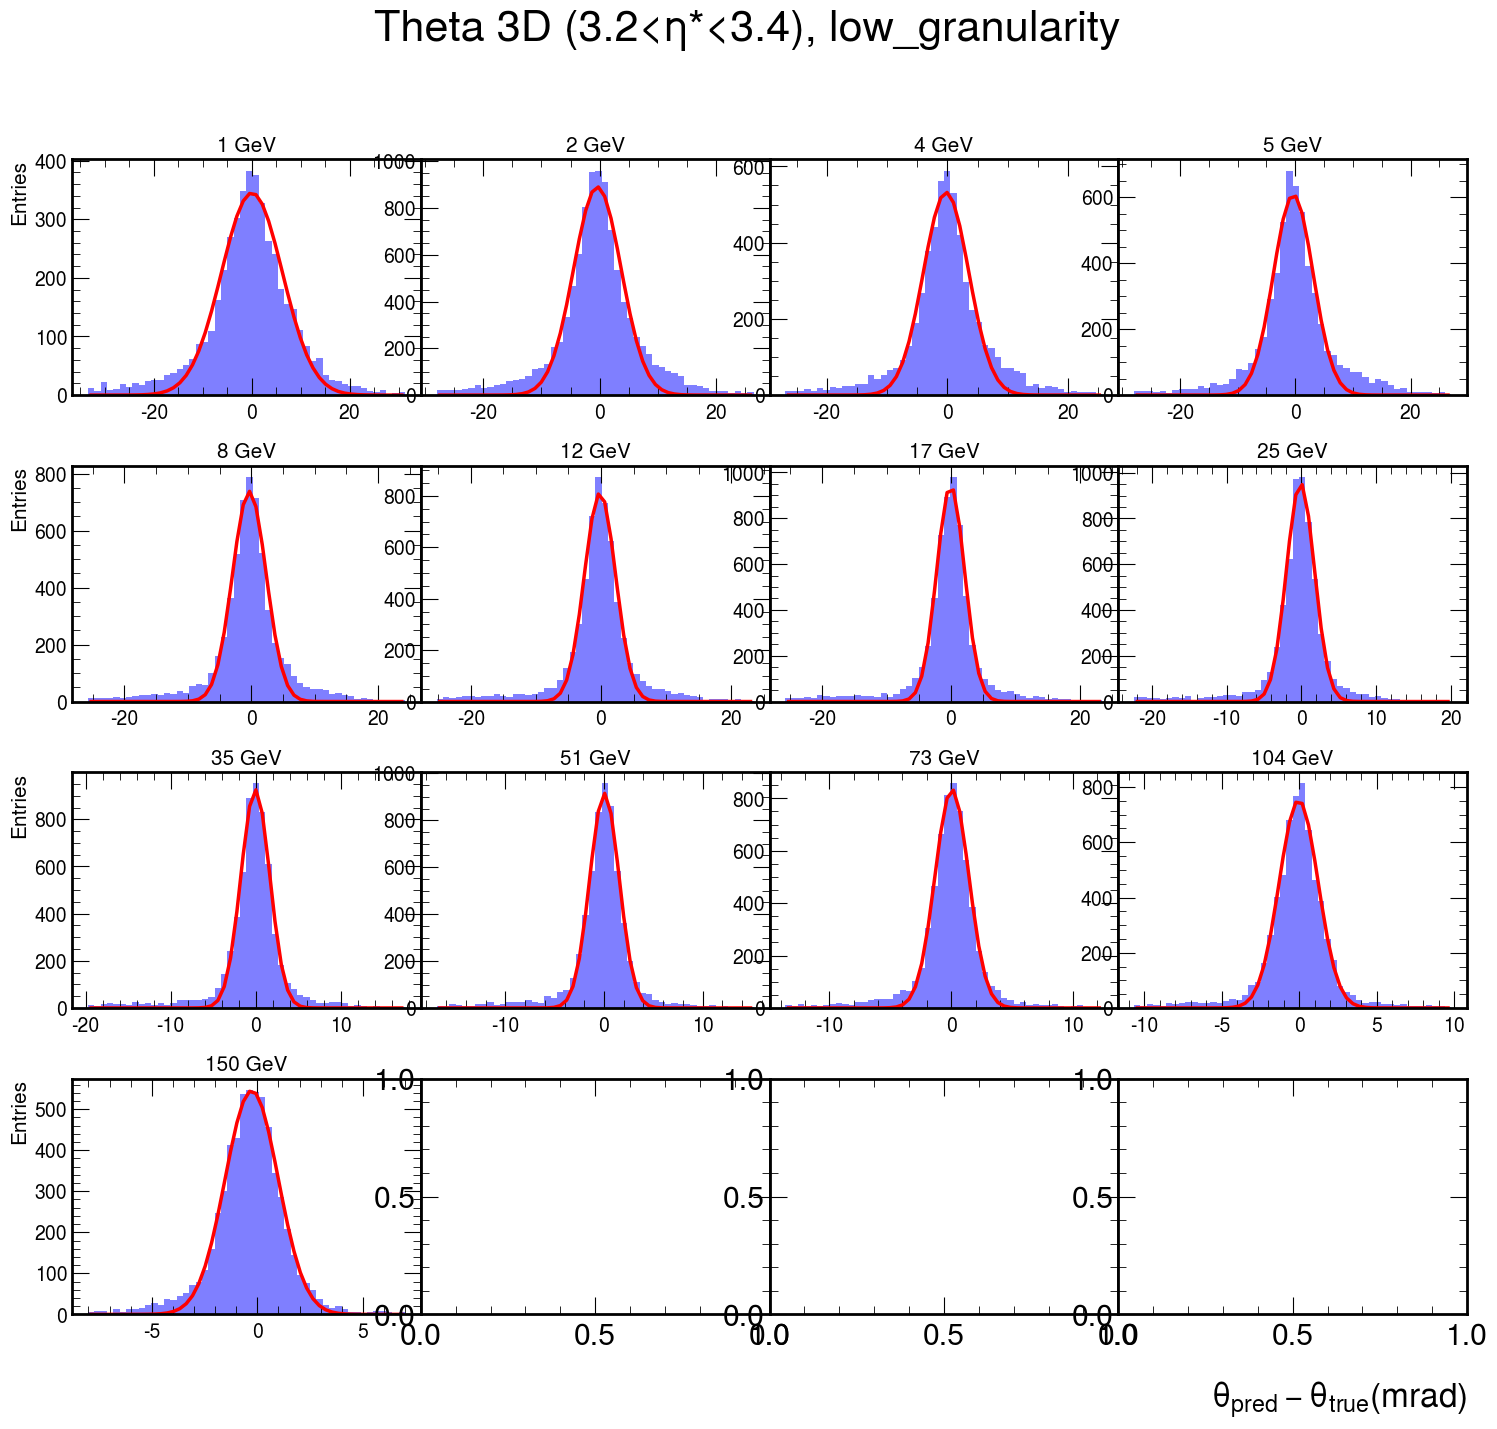

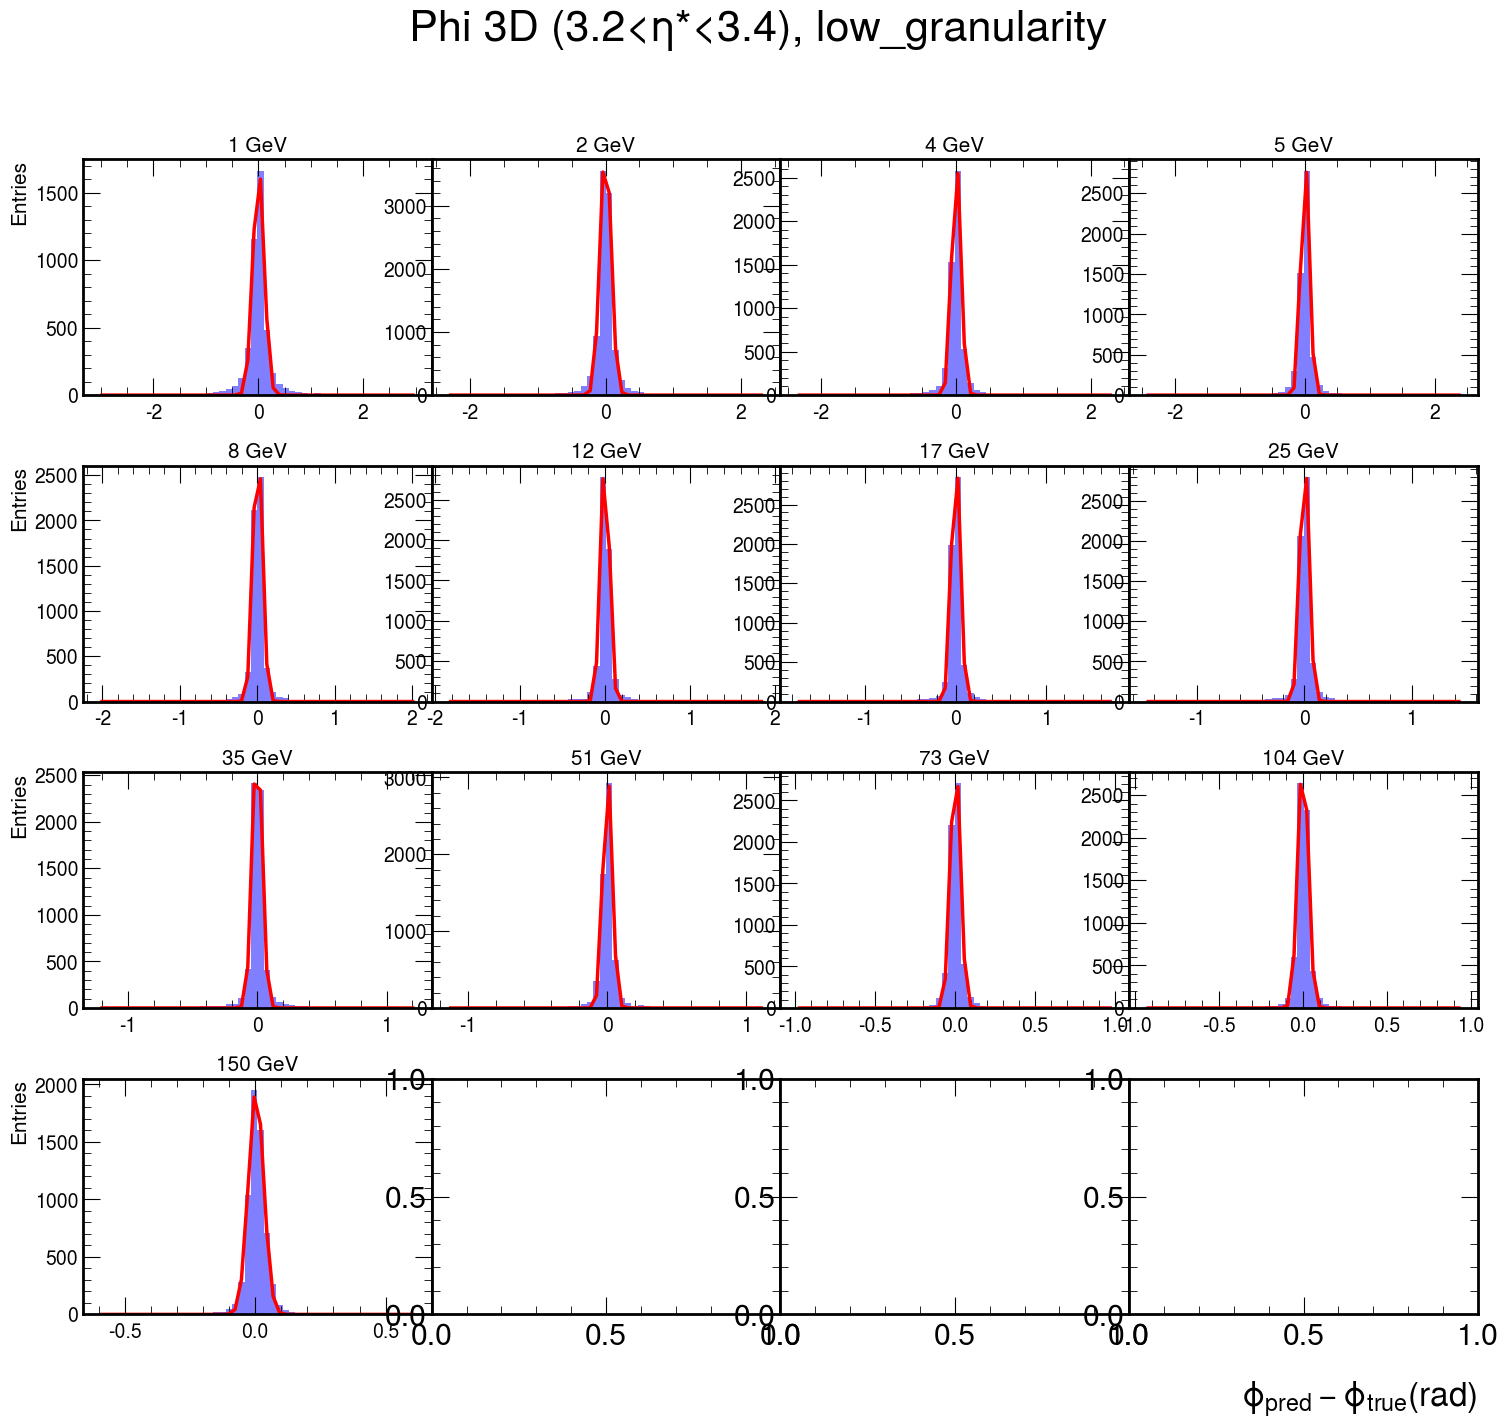

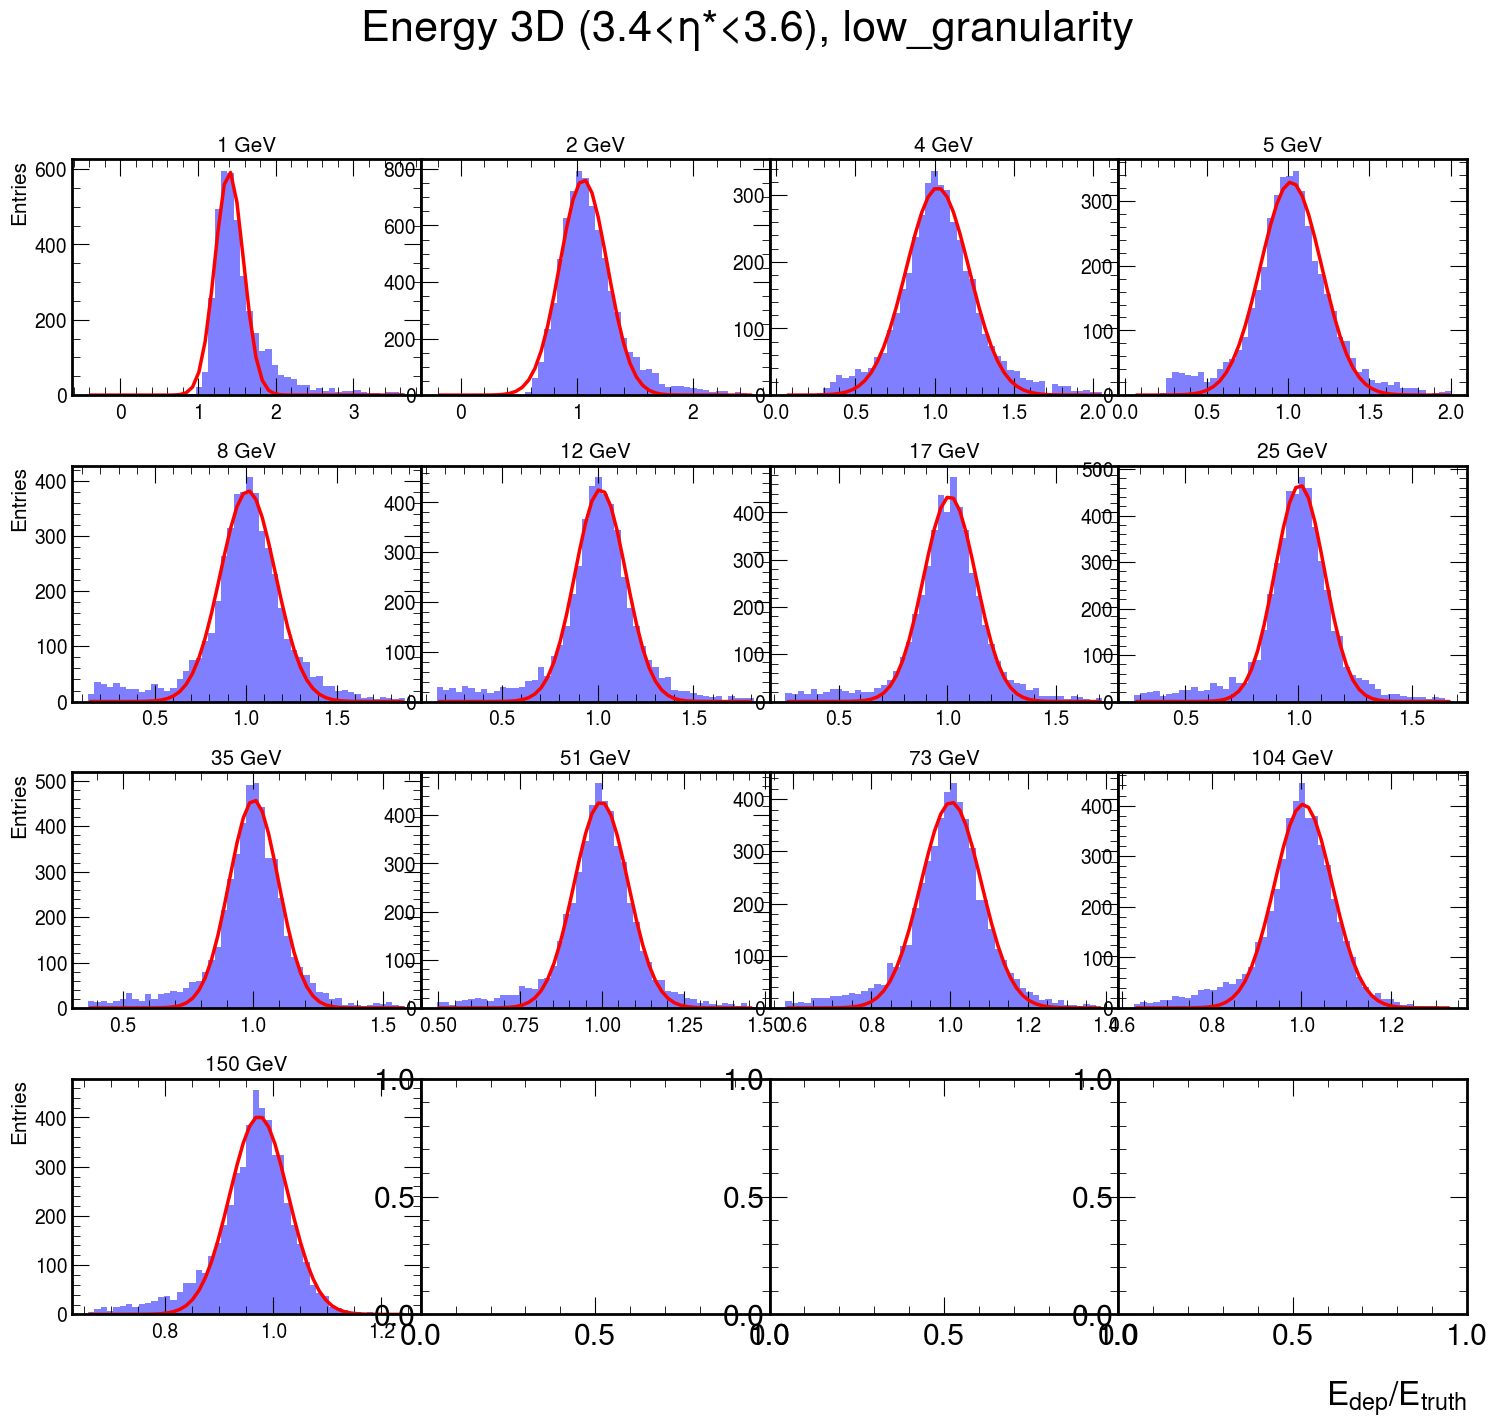

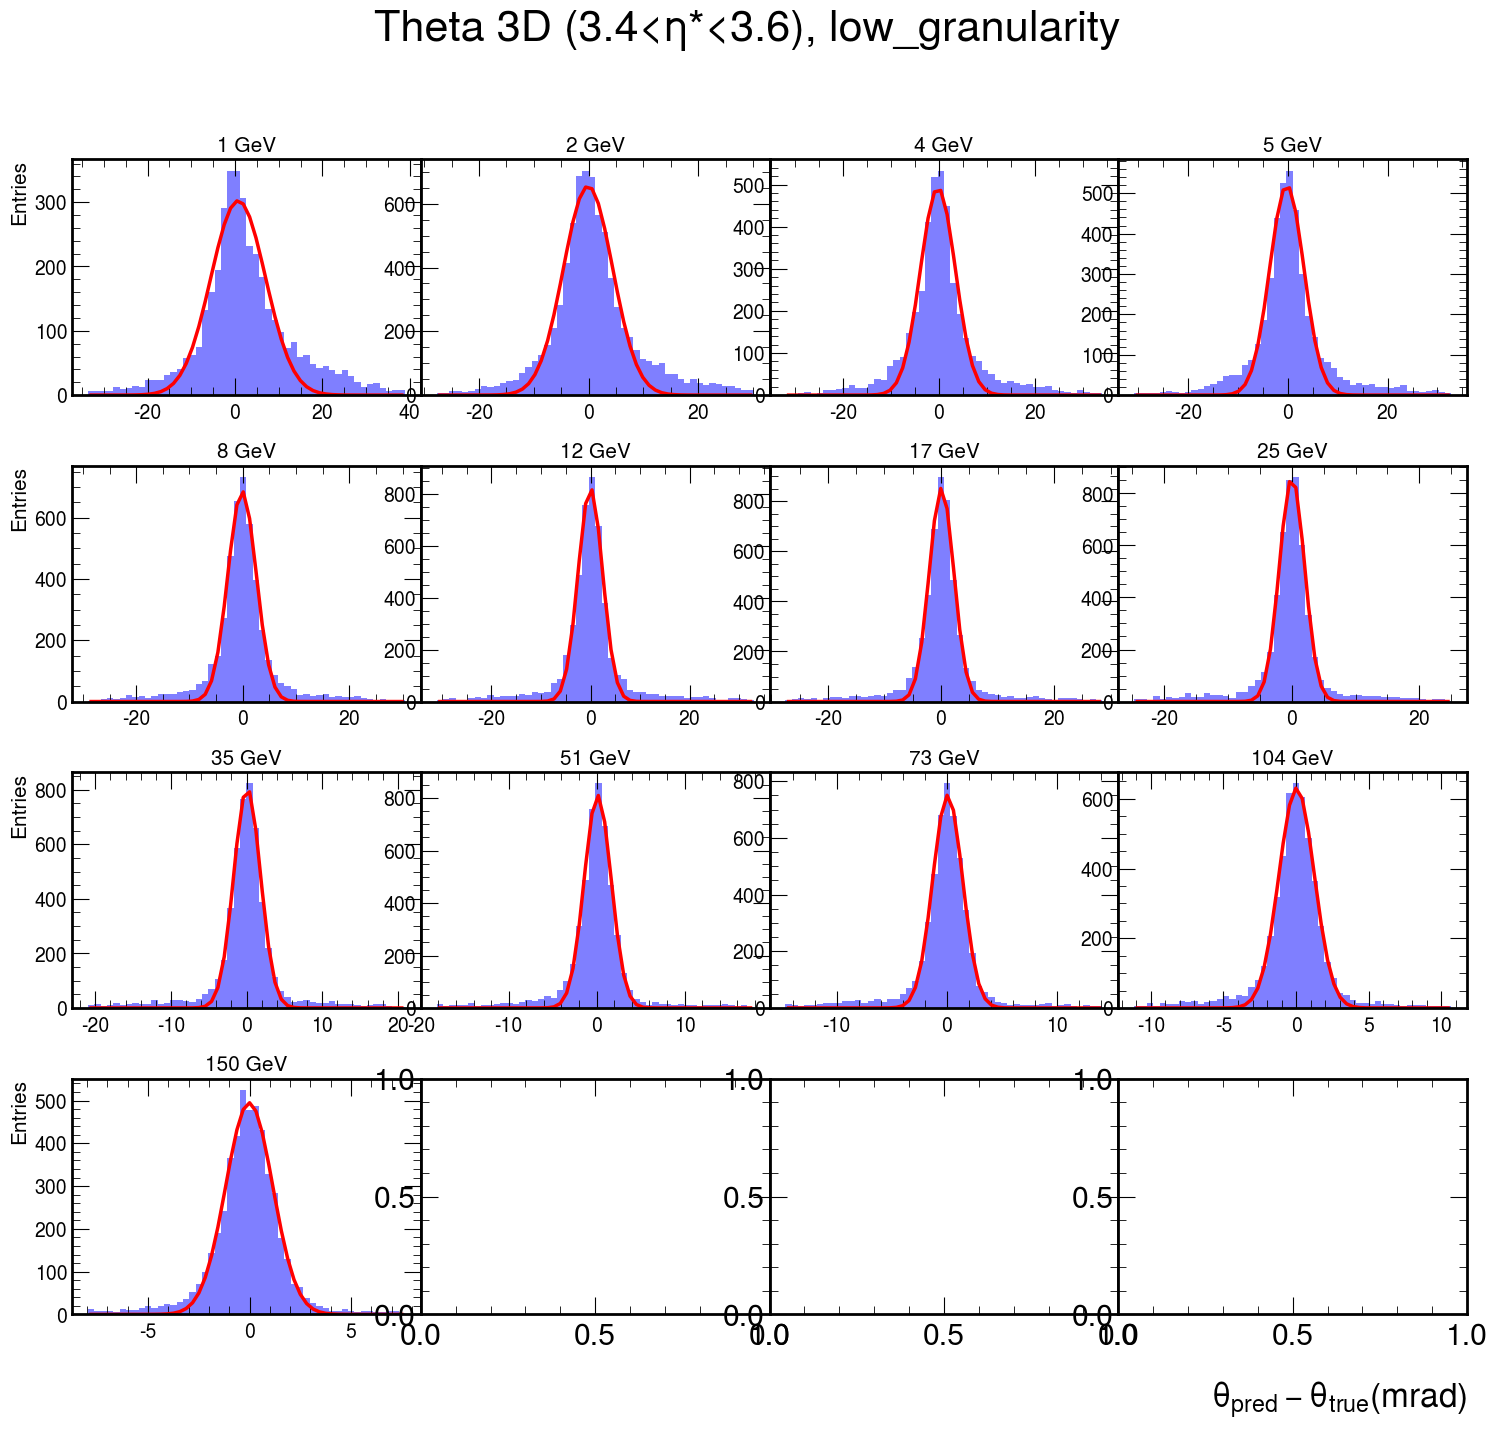

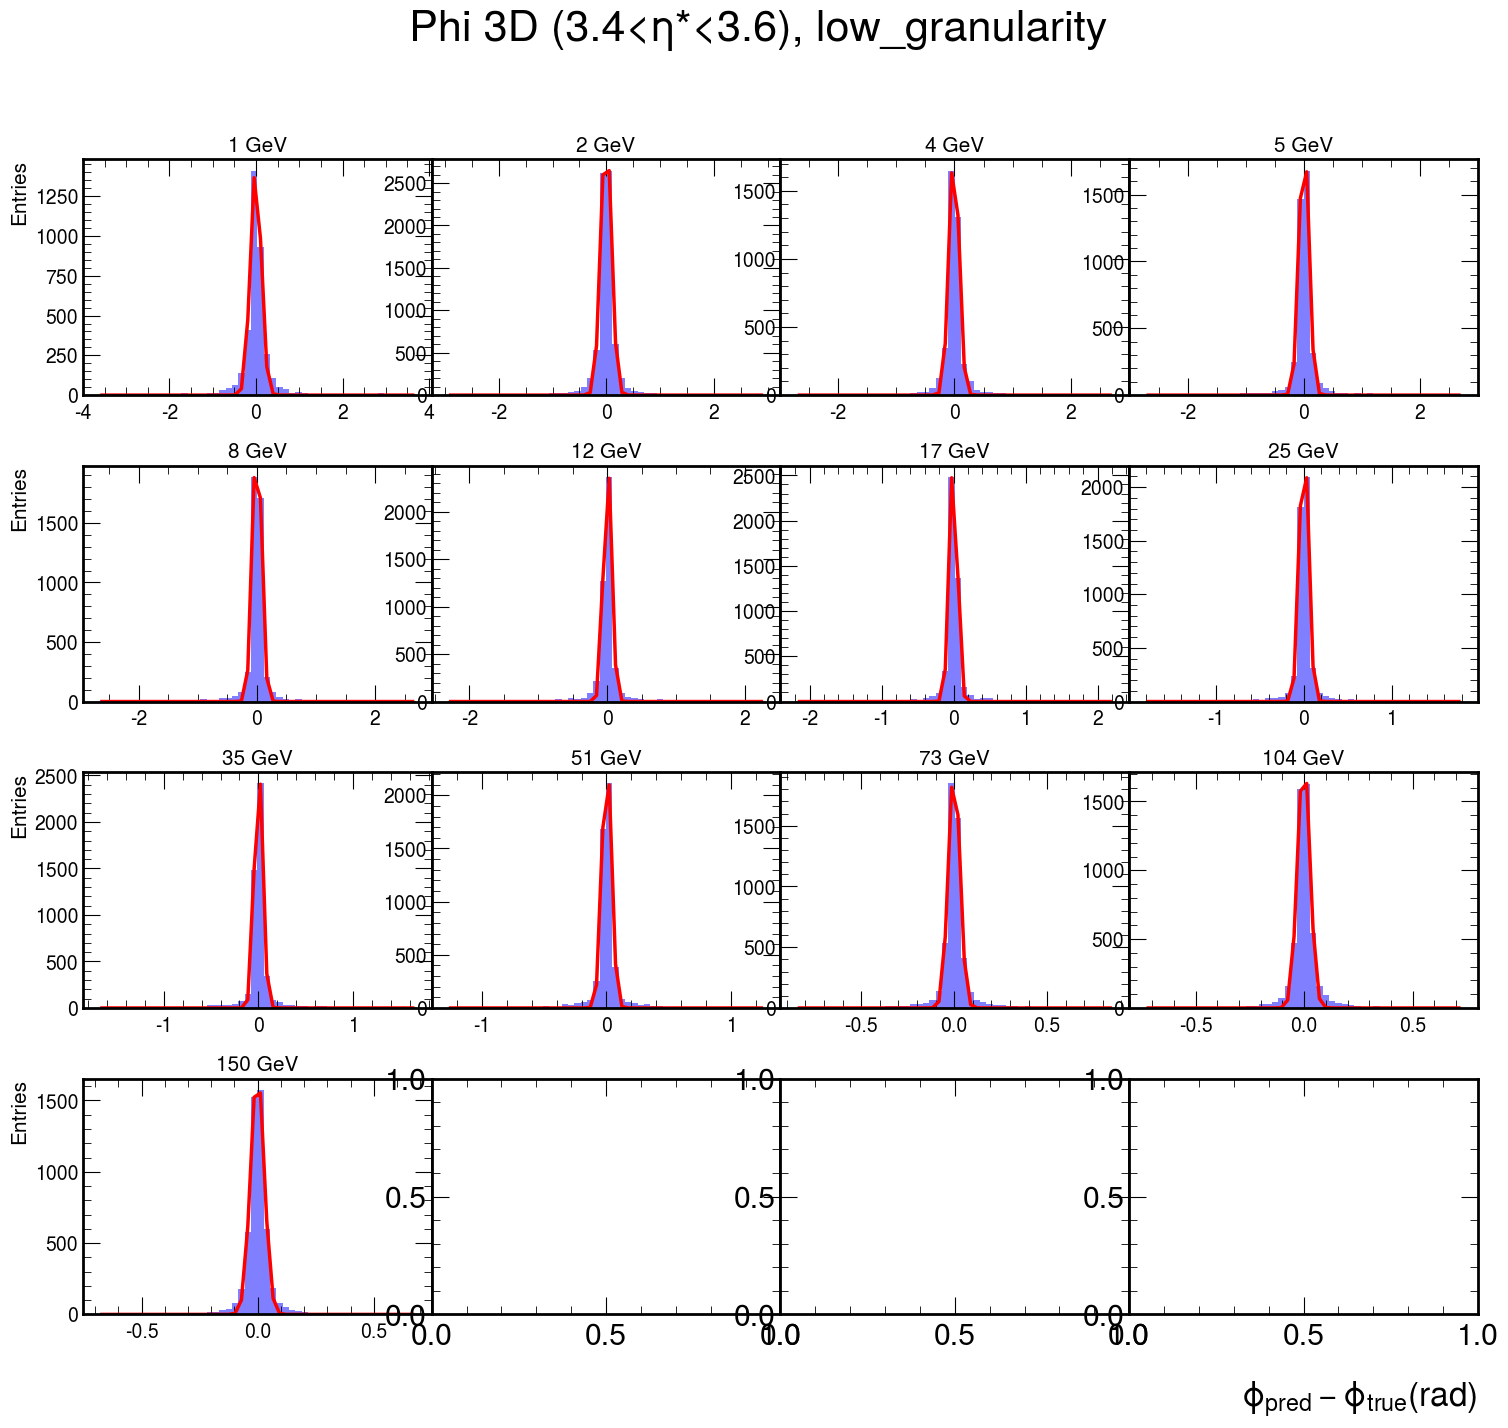

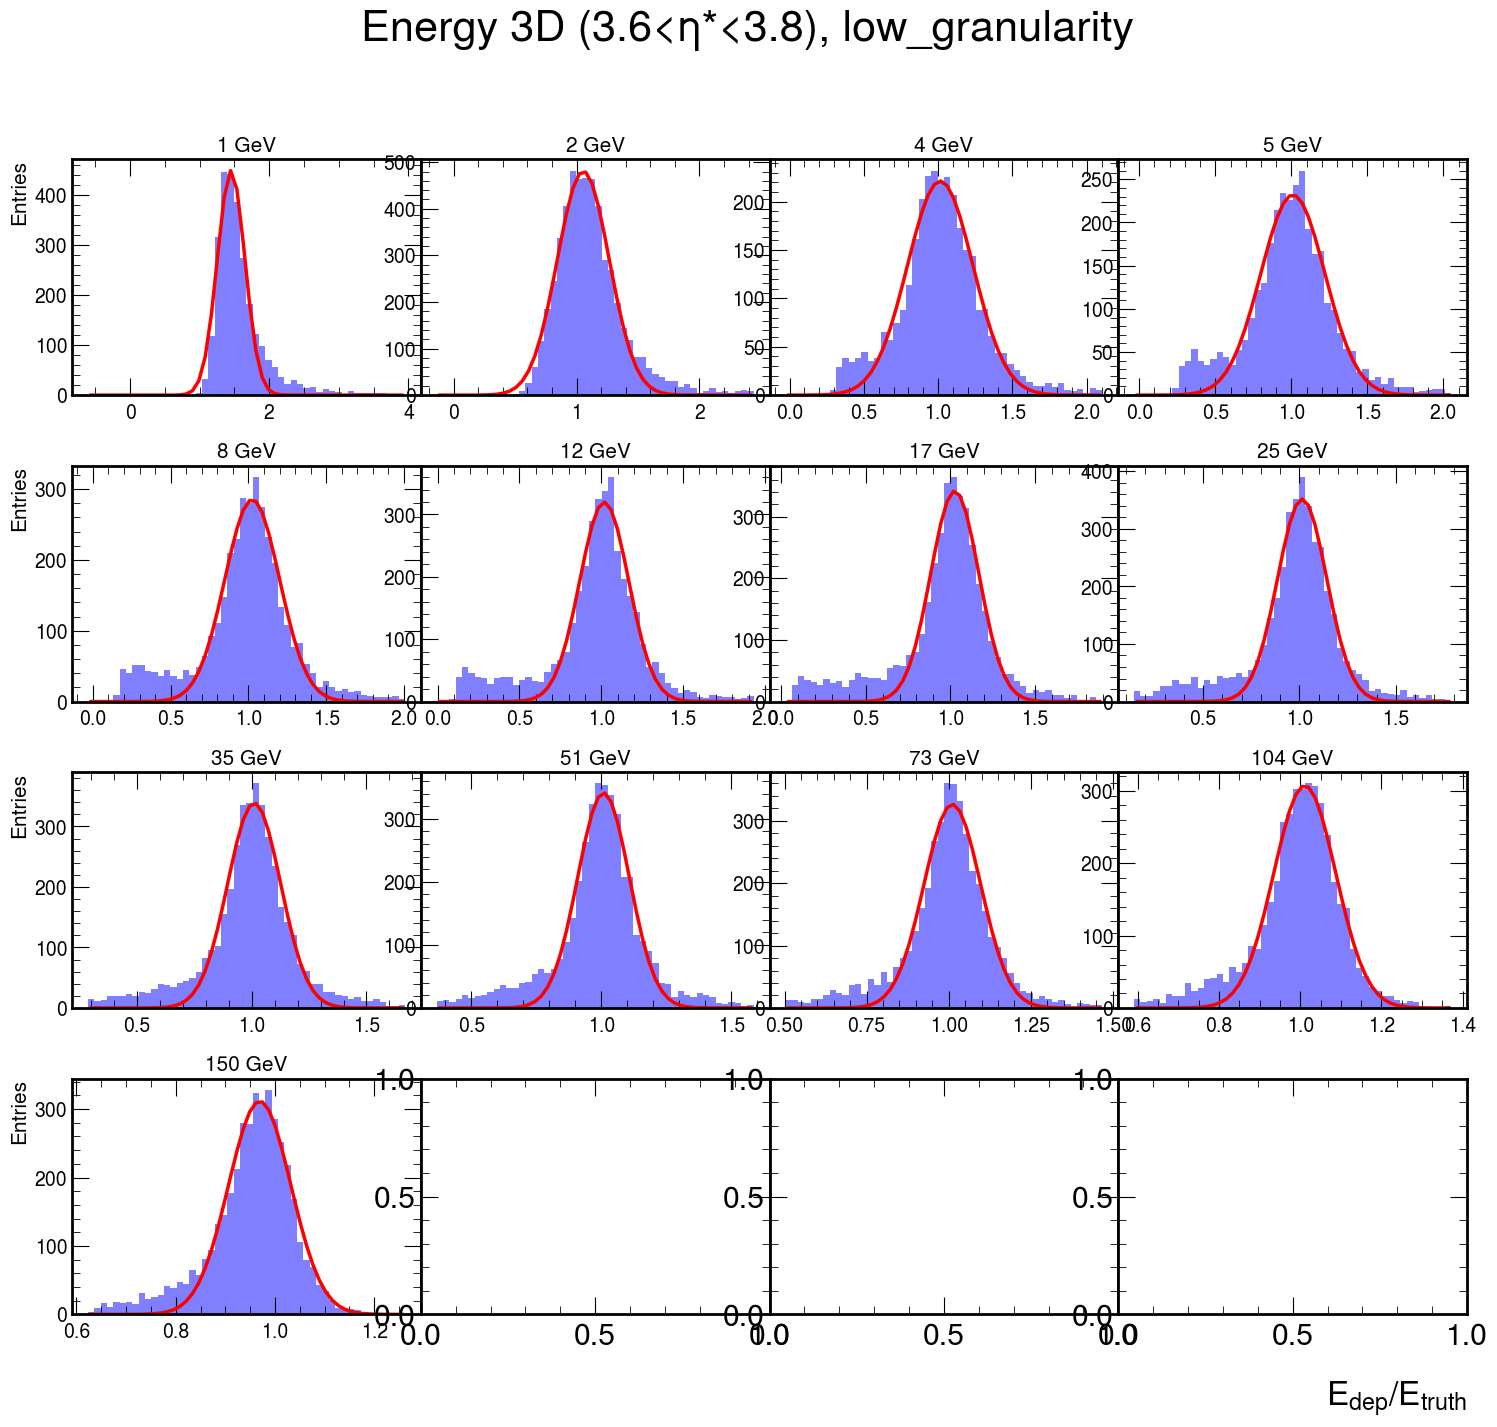

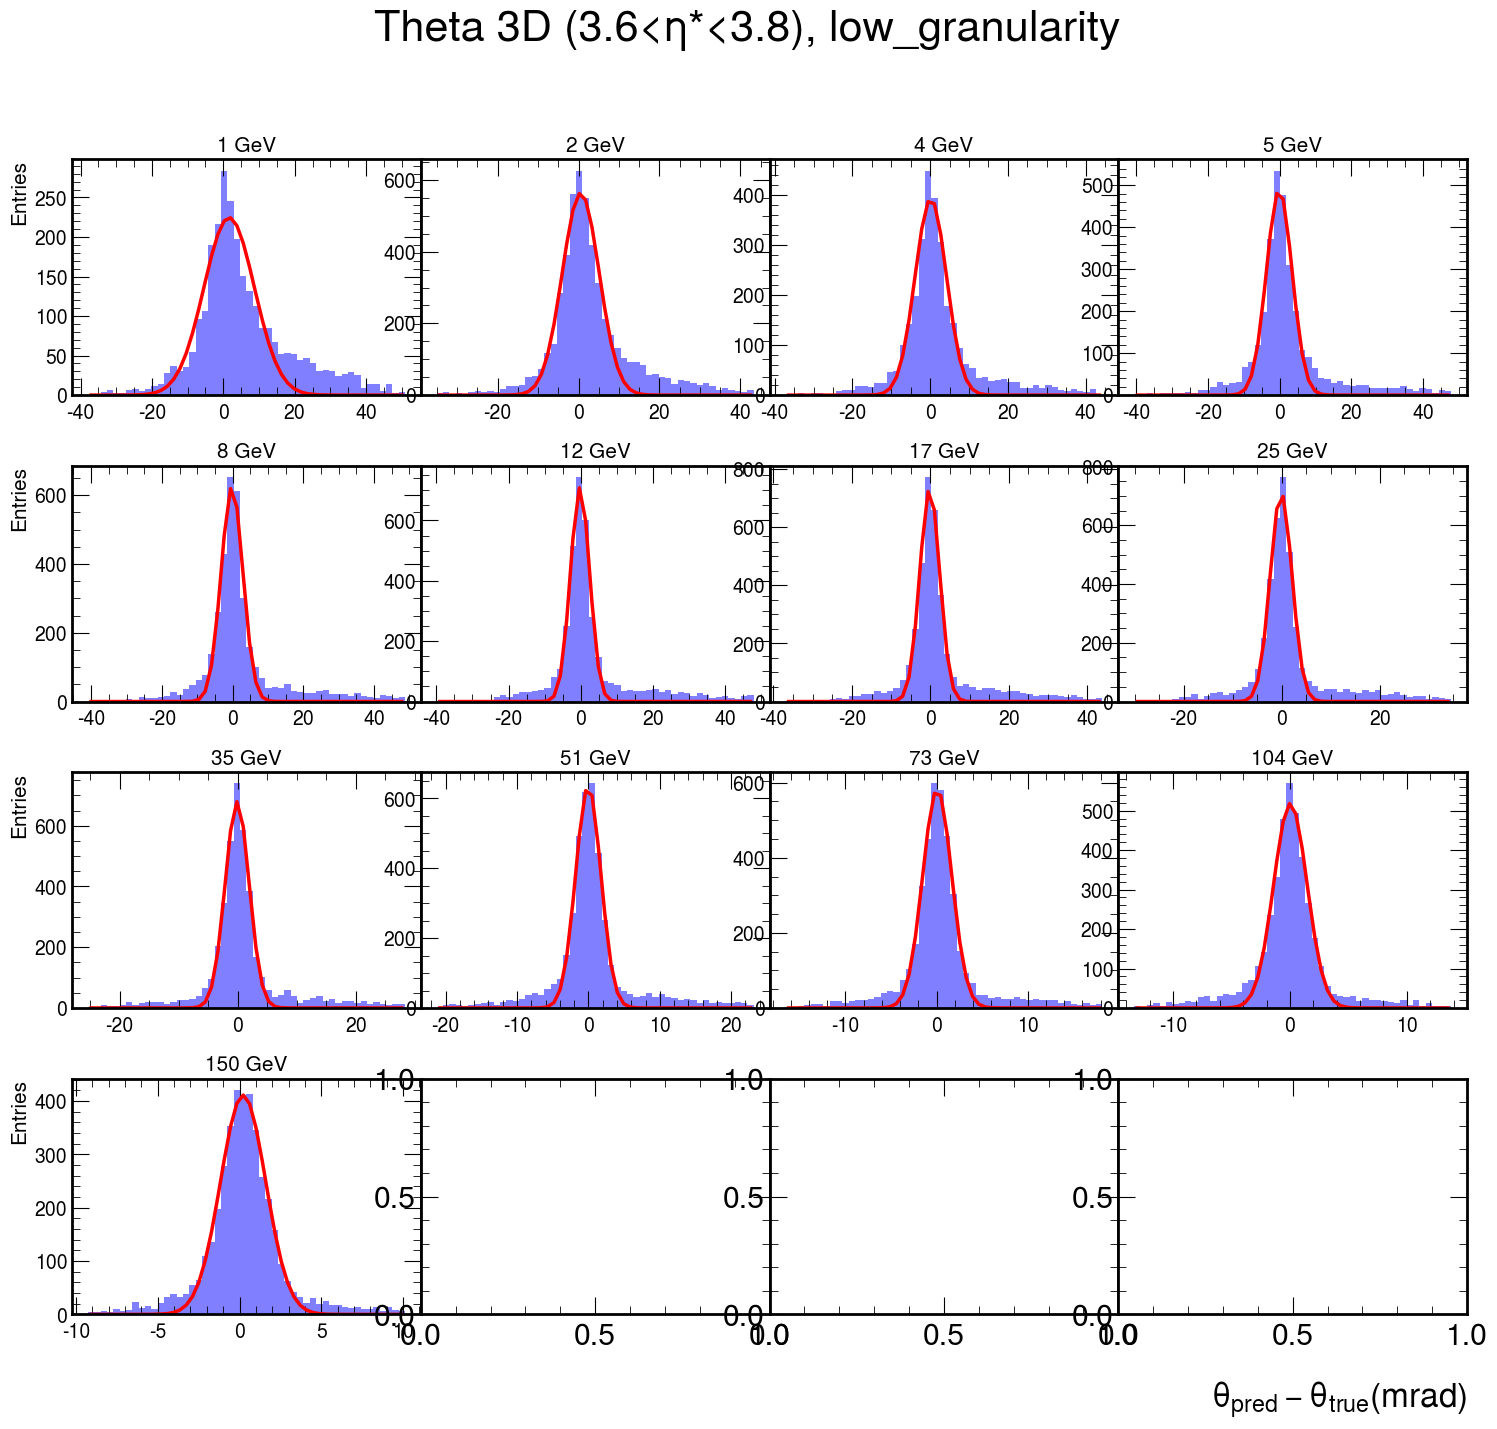

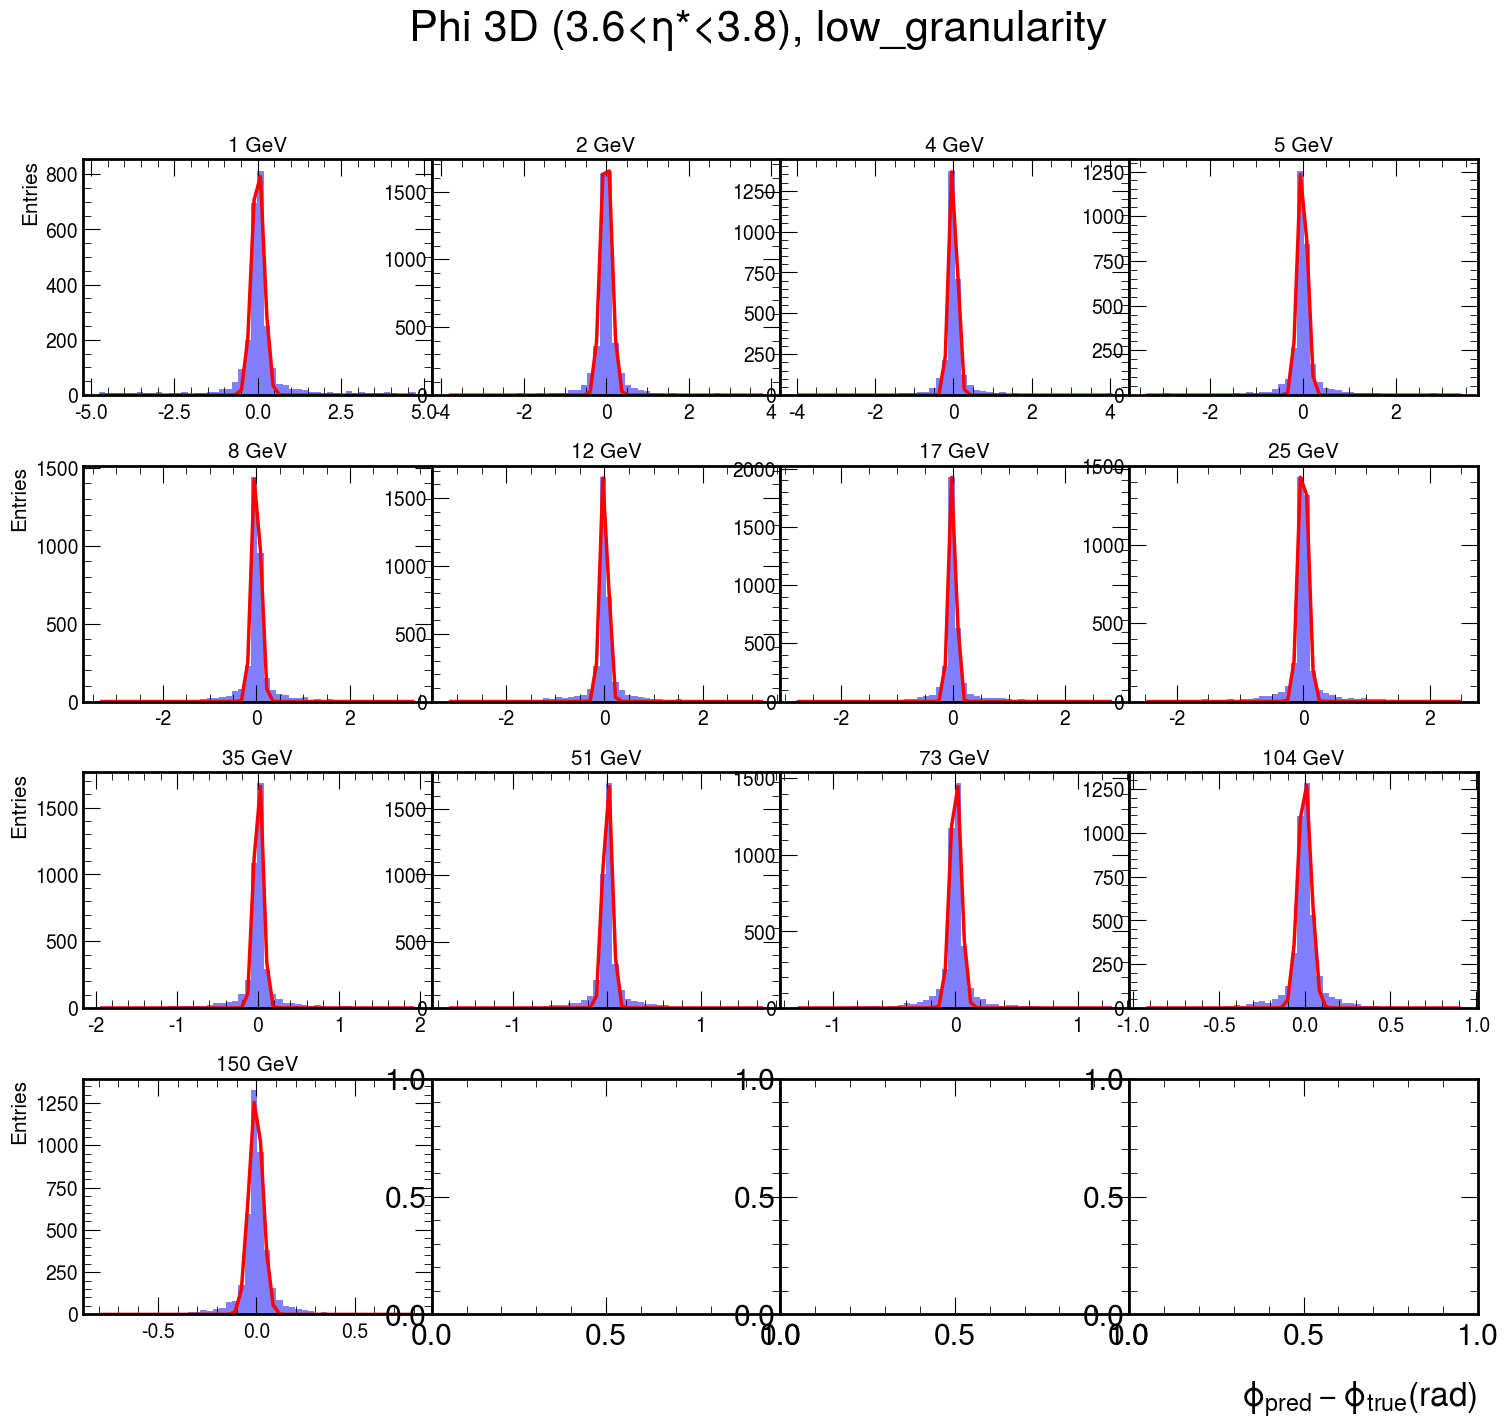

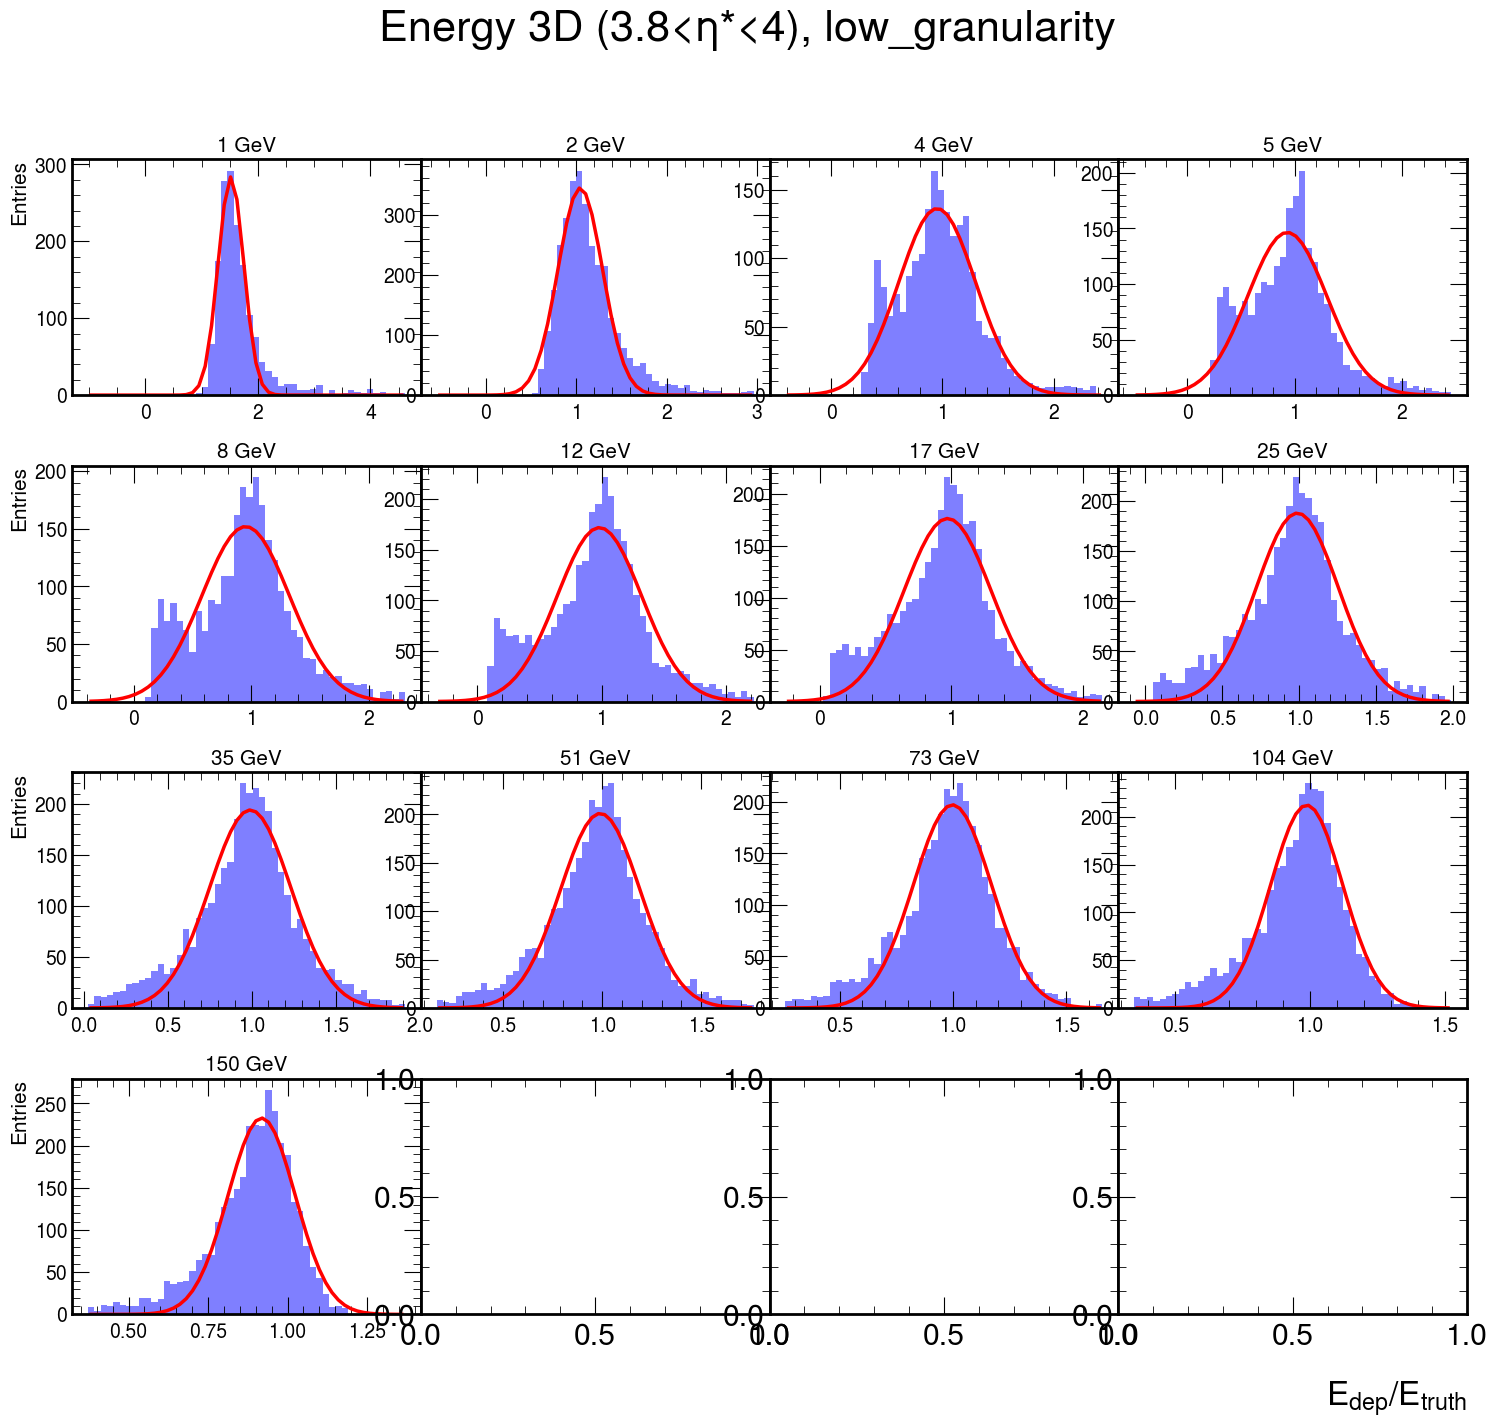

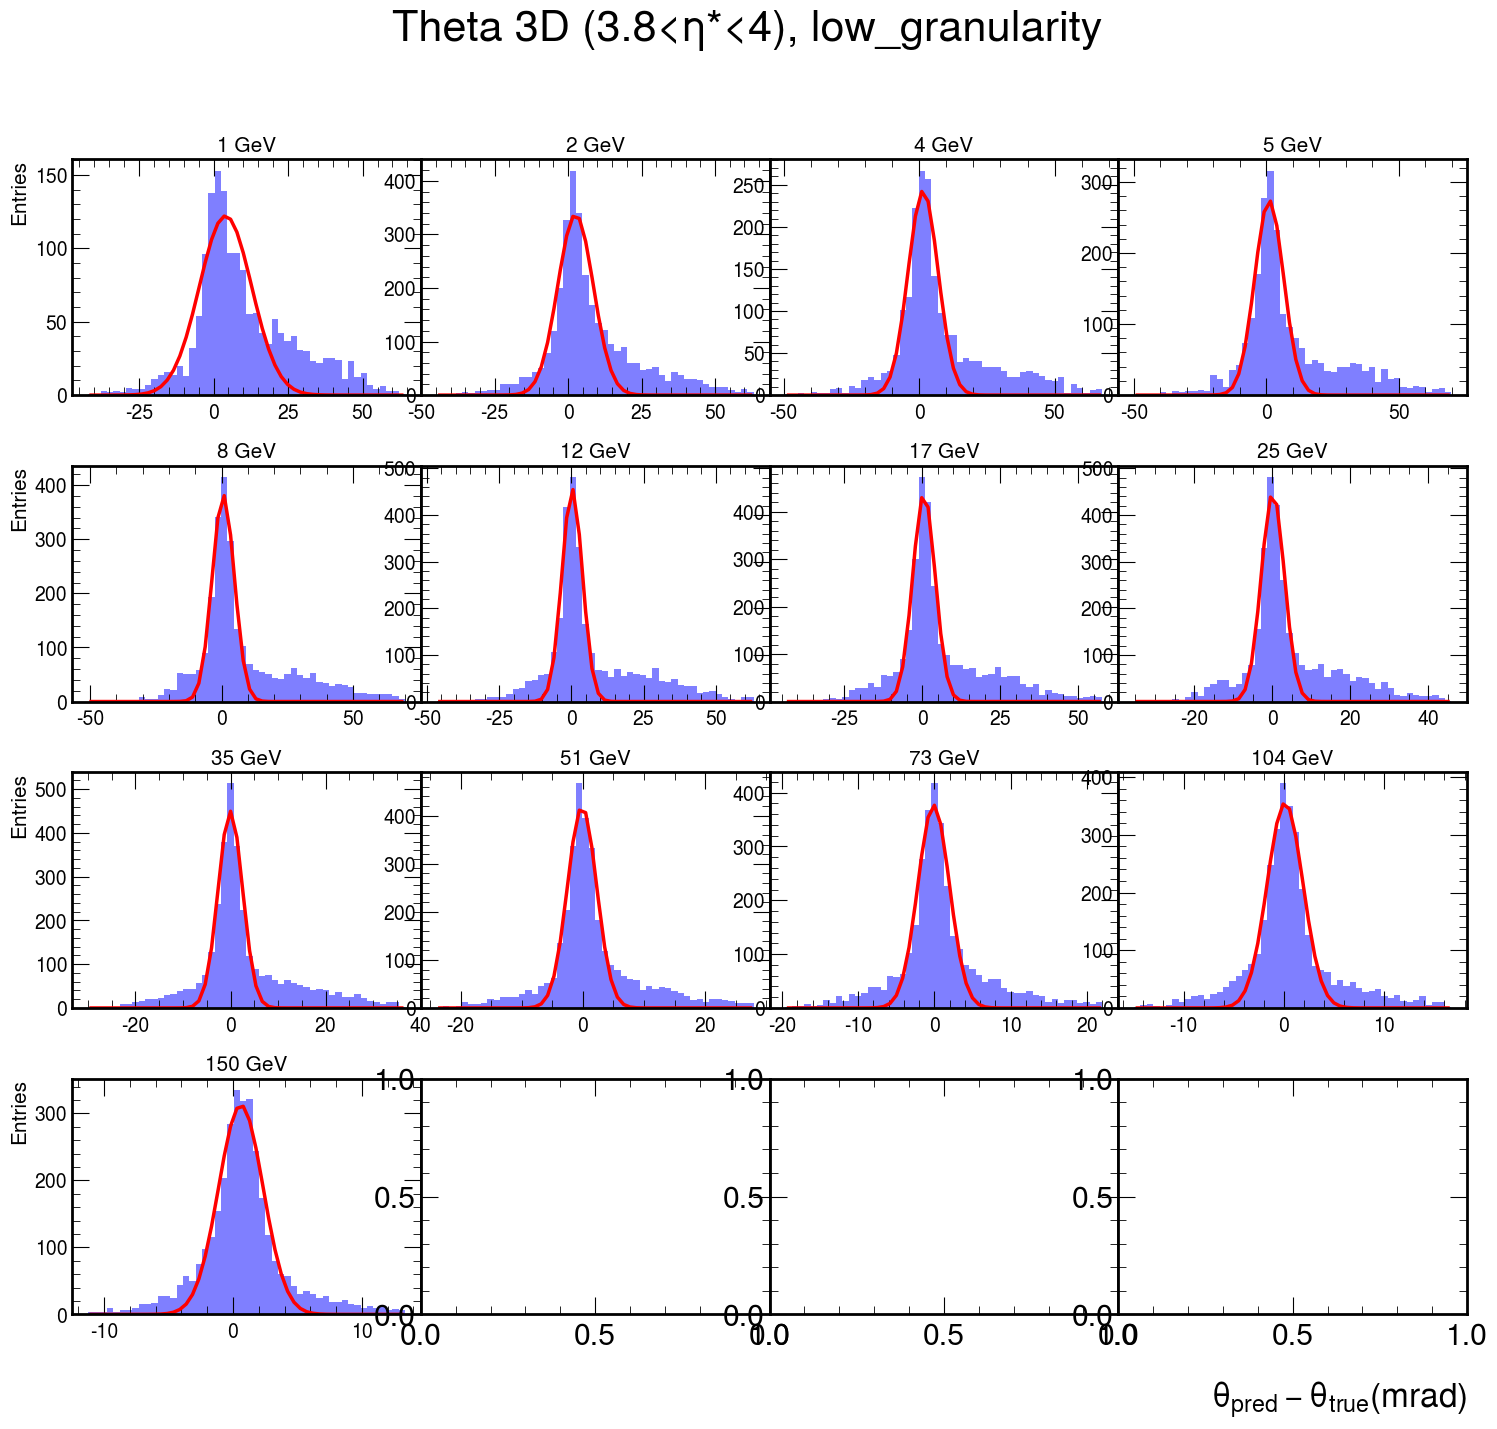

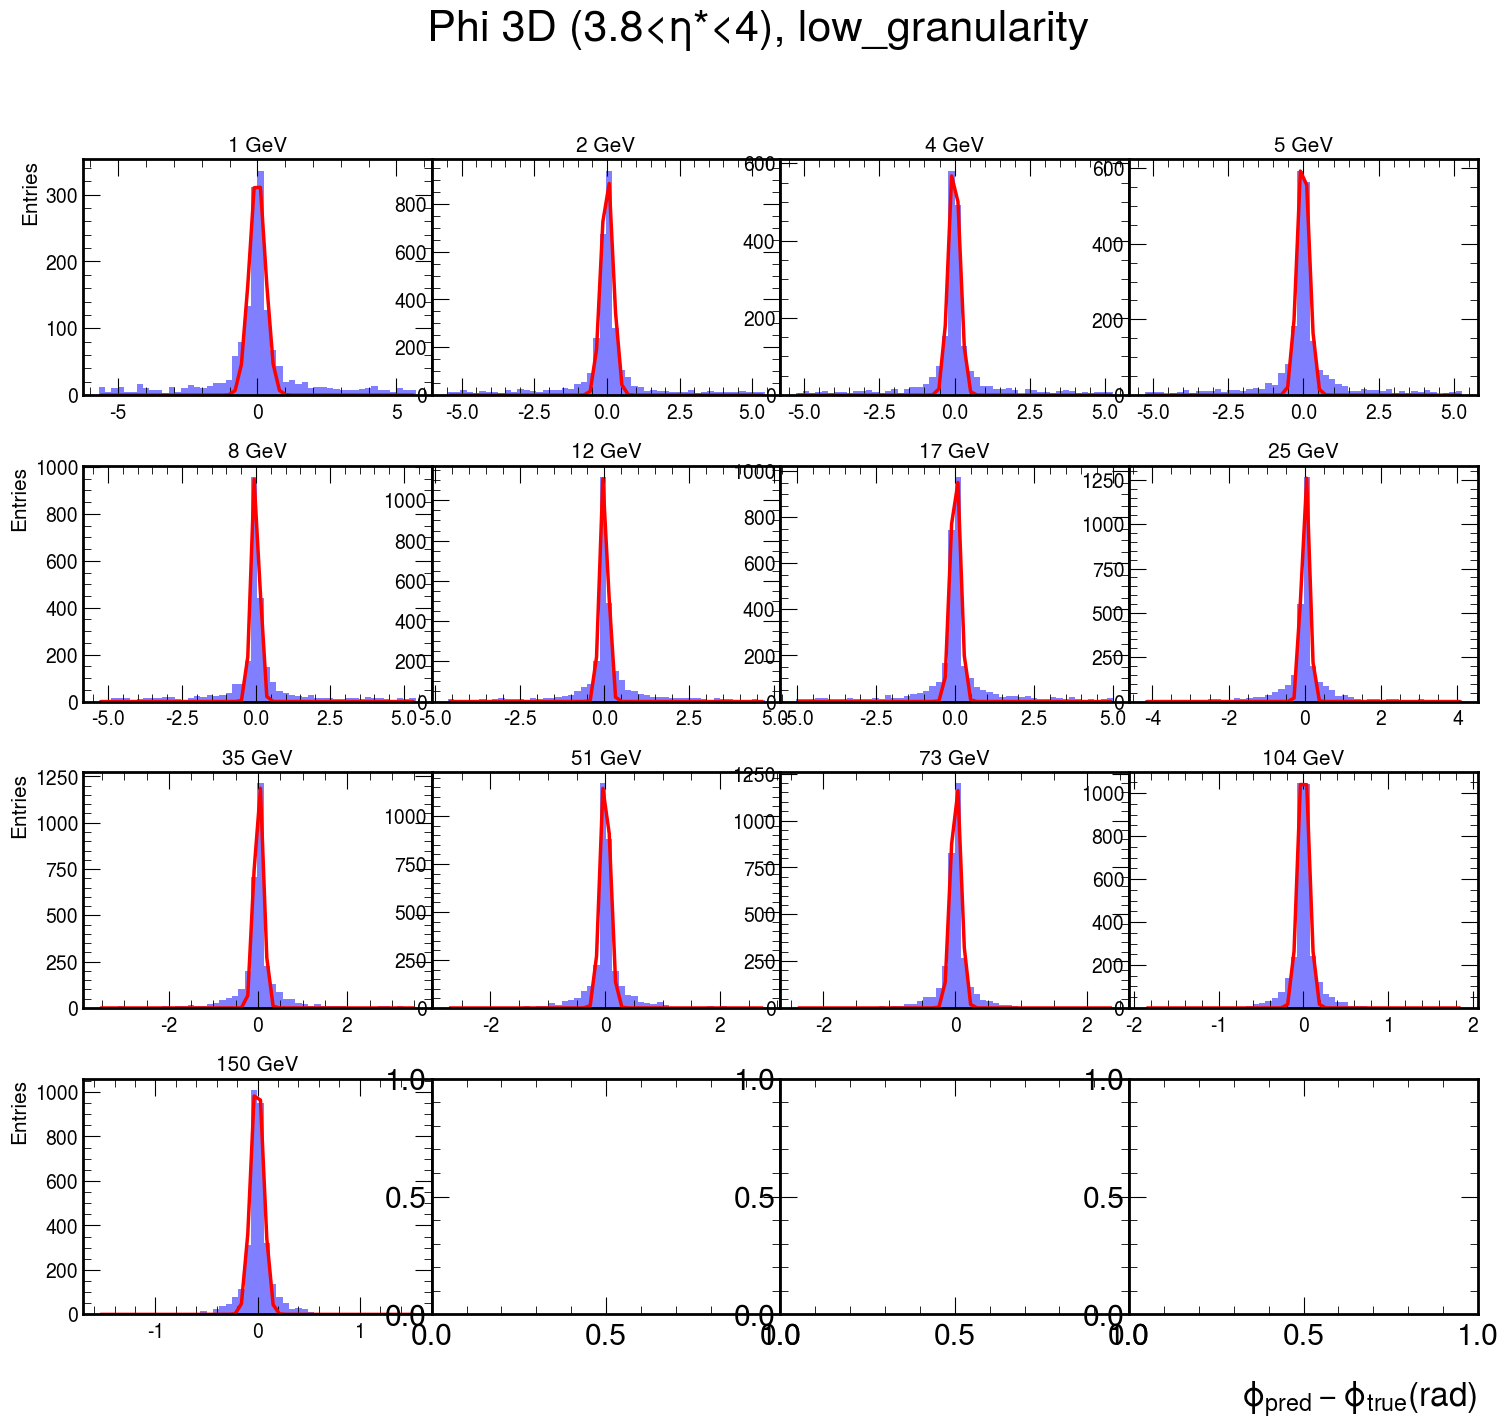

In [9]:
high_granularity_dict.update(get_histograms(high_granularity_dict, high_granularity_parameters, eta_bins))
low_granularity_dict.update(get_histograms(low_granularity_dict, low_granularity_parameters, eta_bins))

In [10]:
plot_title = f"ePIC single neutron: High-granularity vs. Low-granularity insert \n {high_granularity_parameters['date']}, ${high_granularity_parameters['theta_low']:.2f}^{{\circ}}<\\theta^*<{high_granularity_parameters['theta_high']:.2f}^{{\circ}}$"
use_eta_mask = True
if high_granularity_parameters["theta_mask"]:
    plot_title += f"\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask"

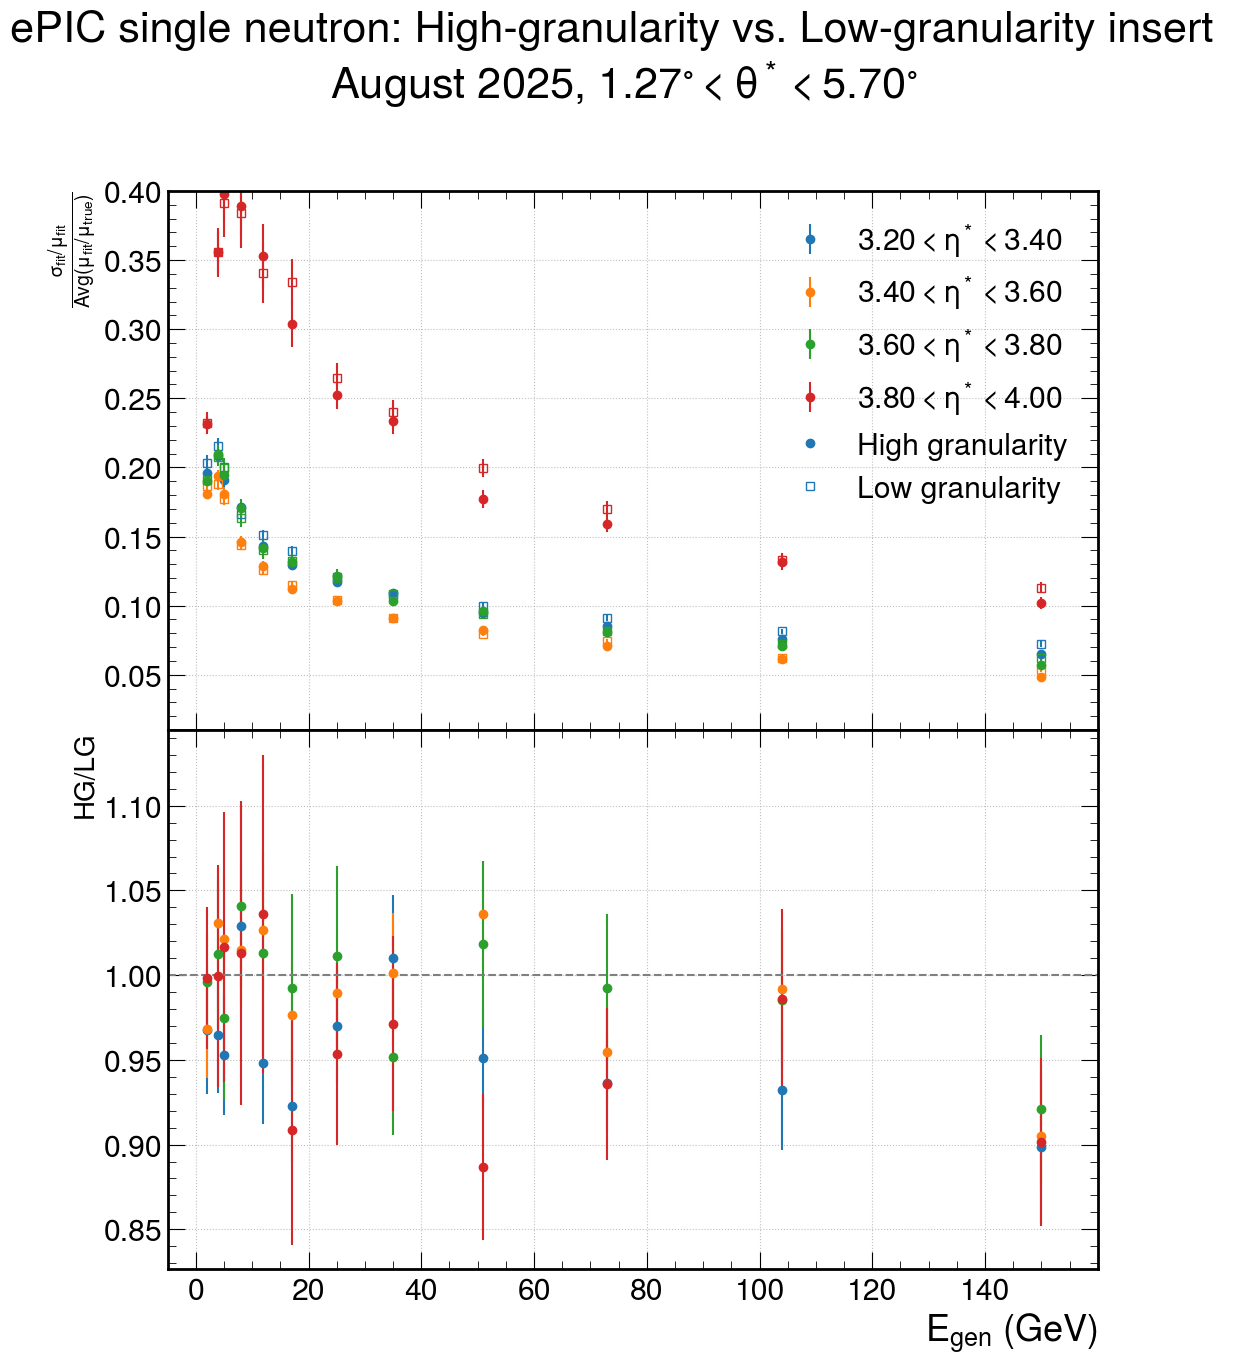

In [11]:
fig = plt.figure(figsize=(12, 14))
fig.set_facecolor('w')
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True, sharey=False)

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    color = color_list[i]

    # High granularity
    hg_truth_energy = high_granularity_dict["eta_truth_energies"][i]
    hg_energy_mask = hg_truth_energy >= lower_energy_lim
    hg_energy_resolution = high_granularity_dict["eta_energy_resolutions"][i][0]
    hg_energy_resolution_error = high_granularity_dict["eta_energy_resolutions"][i][1]
    axs[0].errorbar(
        hg_truth_energy[hg_energy_mask],
        np.asarray(hg_energy_resolution)[hg_energy_mask],
        yerr=np.asarray(hg_energy_resolution_error)[hg_energy_mask],
        marker='o',
        color=color,
        linestyle='none',
        label=f"${eta_range[0]:.2f}<\\eta^*<{eta_range[1]:.2f}$"
    )

    # Low granularity
    lg_truth_energy = low_granularity_dict["eta_truth_energies"][i]
    lg_energy_mask = lg_truth_energy >= lower_energy_lim
    lg_energy_resolution = low_granularity_dict["eta_energy_resolutions"][i][0]
    lg_energy_resolution_error = low_granularity_dict["eta_energy_resolutions"][i][1]
    axs[0].errorbar(
        lg_truth_energy[lg_energy_mask],
        np.asarray(lg_energy_resolution)[lg_energy_mask],
        yerr=np.asarray(lg_energy_resolution_error)[lg_energy_mask],
        marker='s',
        linestyle='none',
        color=color,
        markerfacecolor='none'
    )
    
    ratio, ratio_error = DivideWithErrors(np.array(hg_energy_resolution), np.array(hg_energy_resolution_error), np.array(lg_energy_resolution), np.array(lg_energy_resolution_error))
    
    axs[1].errorbar(
        lg_truth_energy[lg_energy_mask],
        np.asarray(ratio)[lg_energy_mask],
        yerr=np.asarray(ratio_error)[lg_energy_mask],
        marker='o',
        color=color,
        linestyle='none',
    )

high_gran_handle = mlines.Line2D([], [], color=color_list[0], marker='o',
                                 linestyle='none', label='High-granularity')
low_gran_handle  = mlines.Line2D([], [], color=color_list[0], marker='s',
                                 markerfacecolor='none', linestyle='none',
                                 label='Low-granularity')

handles, labels = axs[0].get_legend_handles_labels()
handles.extend([high_gran_handle, low_gran_handle])
labels.extend(['High granularity', 'Low granularity'])
    
axs[0].set_ylabel("$\\frac{\sigma_{fit}/\mu_{fit}}{Avg (\mu_{fit}/\mu_{true})}$",  fontsize=20)
axs[0].set_ylim(0.01, .4)
axs[0].set_xlim(-4.99, 159.99)
axs[0].legend(handles, labels, frameon=False)
axs[1].set_ylabel("HG/LG",  fontsize=20)
axs[1].set_xlabel("$E_{gen}$ (GeV)")
axs[0].grid()
axs[1].grid()
axs[1].hlines(y=1, xmin=-4.99, xmax=159.99, color='gray', linestyle='dashed')
if use_eta_mask:
    plt.suptitle(plot_title, y=1.01)
else:
    plt.suptitle(plot_title, y=.99)

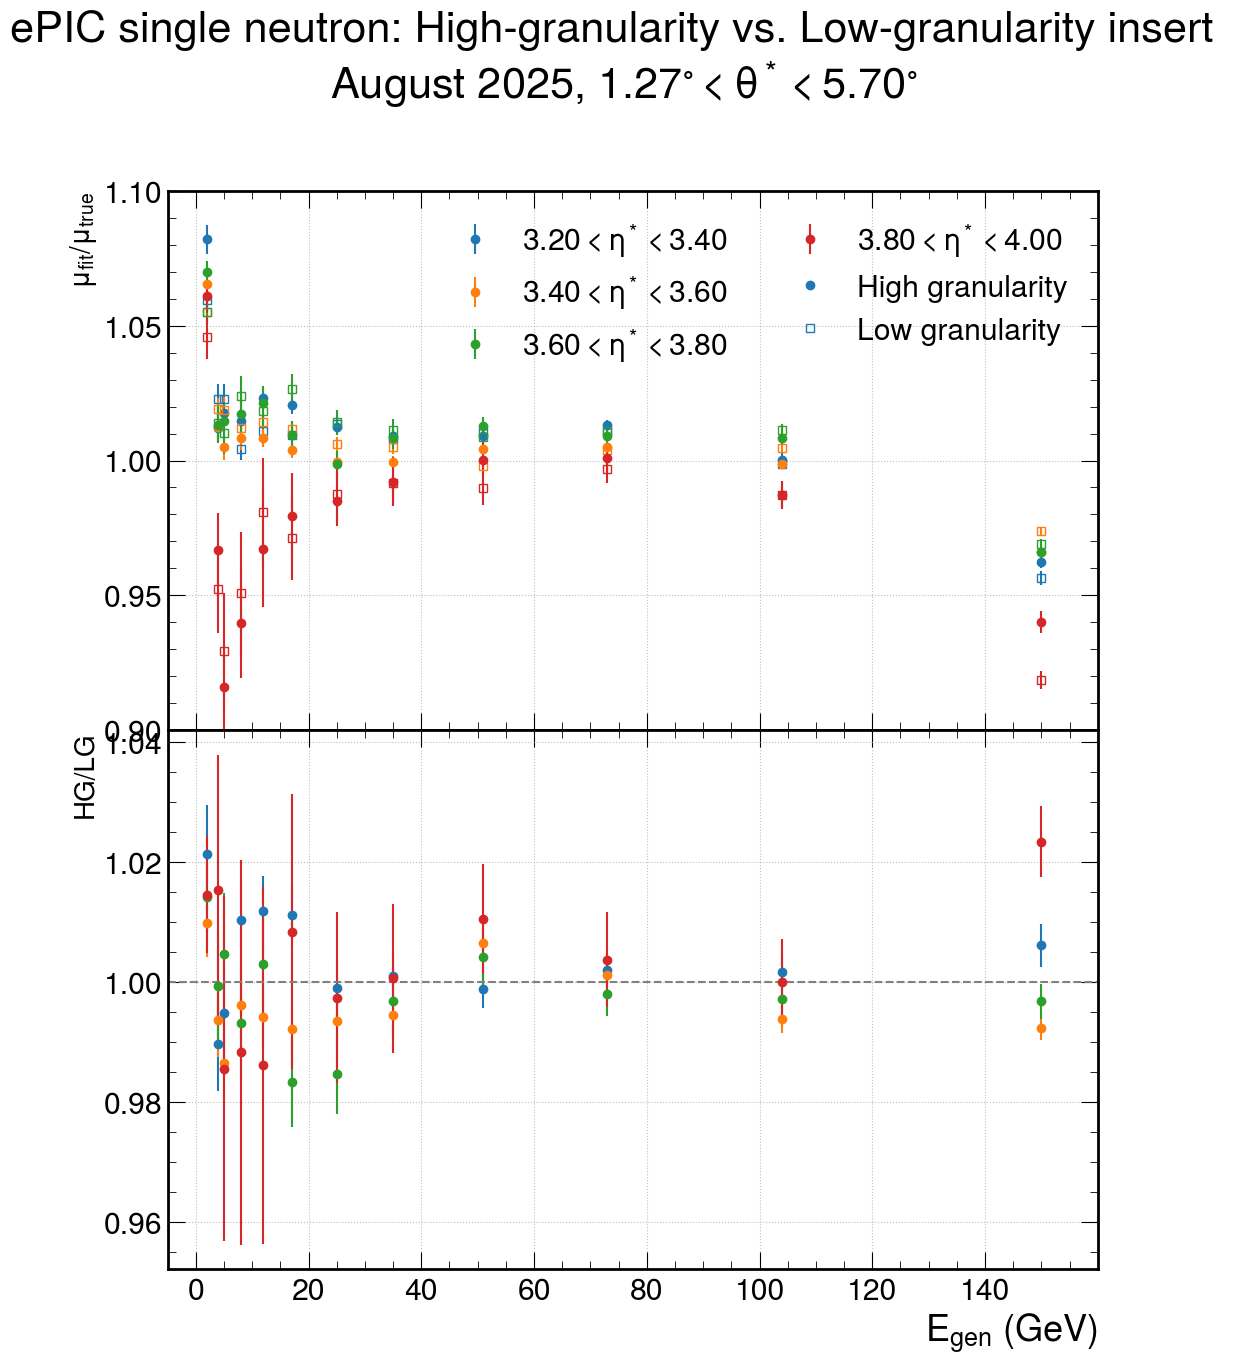

In [12]:
fig = plt.figure(figsize=(12, 14))
fig.set_facecolor('w')
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True, sharey=False)

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    color = color_list[i]

    # High granularity
    hg_truth_energy = high_granularity_dict["eta_truth_energies"][i]
    hg_energy_mask = hg_truth_energy >= lower_energy_lim
    hg_energy_scale = high_granularity_dict["eta_energy_scales"][i][0]
    hg_energy_scale_error = high_granularity_dict["eta_energy_scales"][i][1]
    axs[0].errorbar(
        hg_truth_energy[hg_energy_mask],
        np.asarray(hg_energy_scale)[hg_energy_mask],
        yerr=np.asarray(hg_energy_scale_error)[hg_energy_mask],
        marker='o',
        color=color,
        linestyle='none',
        label=f"${eta_range[0]:.2f}<\\eta^*<{eta_range[1]:.2f}$"
    )

    # Low granularity
    lg_truth_energy = low_granularity_dict["eta_truth_energies"][i]
    lg_energy_mask = lg_truth_energy >= lower_energy_lim
    lg_energy_scale = low_granularity_dict["eta_energy_scales"][i][0]
    lg_energy_scale_error = low_granularity_dict["eta_energy_scales"][i][1]
    axs[0].errorbar(
        lg_truth_energy[lg_energy_mask],
        np.asarray(lg_energy_scale)[lg_energy_mask],
        yerr=np.asarray(lg_energy_scale_error)[lg_energy_mask],
        marker='s',
        linestyle='none',
        color=color,
        markerfacecolor='none'
    )
    
    ratio, ratio_error = DivideWithErrors(np.array(hg_energy_scale), np.array(hg_energy_scale_error), np.array(lg_energy_scale), np.array(lg_energy_scale_error))
    
    axs[1].errorbar(
        lg_truth_energy[lg_energy_mask],
        np.asarray(ratio)[lg_energy_mask],
        yerr=np.asarray(ratio_error)[lg_energy_mask],
        marker='o',
        color=color,
        linestyle='none',
    )

high_gran_handle = mlines.Line2D([], [], color=color_list[0], marker='o',
                                 linestyle='none', label='High-granularity')
low_gran_handle  = mlines.Line2D([], [], color=color_list[0], marker='s',
                                 markerfacecolor='none', linestyle='none',
                                 label='Low-granularity')

handles, labels = axs[0].get_legend_handles_labels()
handles.extend([high_gran_handle, low_gran_handle])
labels.extend(['High granularity', 'Low granularity'])
    
axs[0].set_ylabel("$\mu_{fit}/\mu_{true}$",  fontsize=20)
axs[0].set_ylim(.9, 1.1)
axs[0].set_xlim(-4.99, 159.99)
axs[0].legend(handles, labels, frameon=False, ncols=2)
axs[1].set_ylabel("HG/LG",  fontsize=20)
axs[1].set_xlabel("$E_{gen}$ (GeV)")
axs[0].grid()
axs[1].grid()
axs[1].hlines(y=1, xmin=-4.99, xmax=159.99, color='gray', linestyle='dashed')
if use_eta_mask:
    plt.suptitle(plot_title, y=1.01)
else:
    plt.suptitle(plot_title, y=.99)

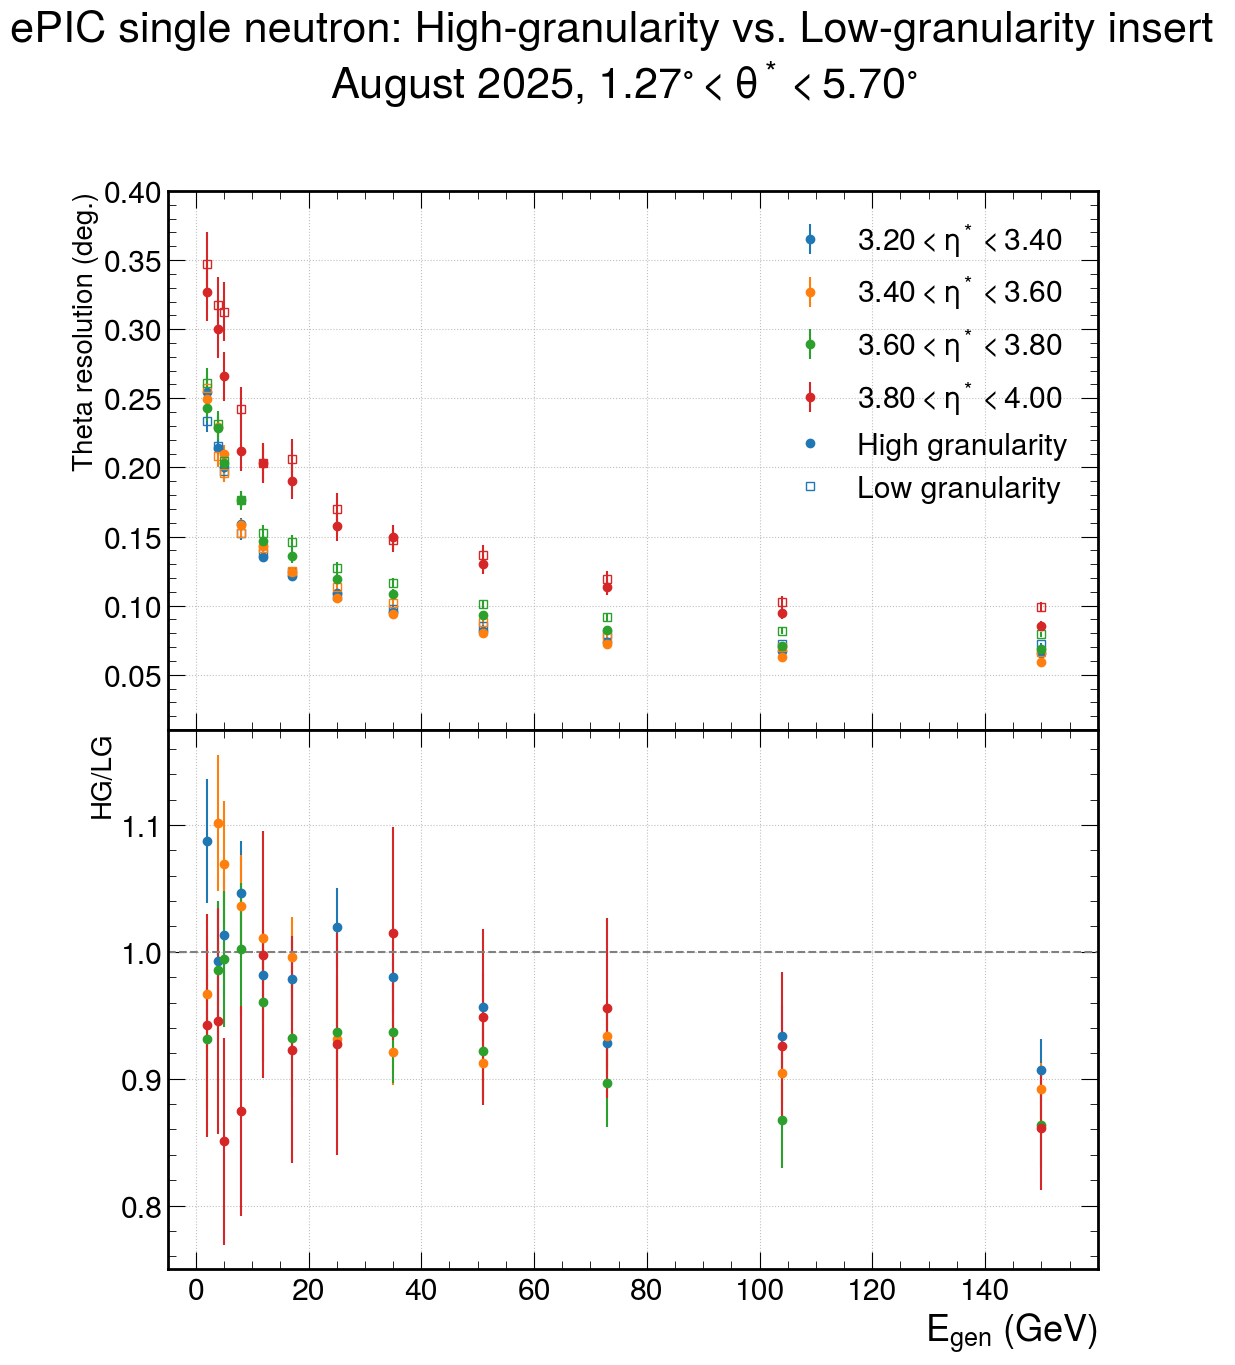

In [13]:
fig = plt.figure(figsize=(12, 14))
fig.set_facecolor('w')
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True, sharey=False)

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    color = color_list[i]

    # High granularity
    hg_truth_energy = high_granularity_dict["eta_truth_energies"][i]
    hg_energy_mask = hg_truth_energy >= lower_energy_lim
    hg_theta_resolution = np.array(high_granularity_dict["eta_theta_resolutions"][i][0])/1000*180/np.pi
    hg_theta_resolution_error = np.array(high_granularity_dict["eta_theta_resolutions"][i][1])/1000*180/np.pi
    axs[0].errorbar(
        hg_truth_energy[hg_energy_mask],
        np.asarray(hg_theta_resolution)[hg_energy_mask],
        yerr=np.asarray(hg_theta_resolution_error)[hg_energy_mask],
        marker='o',
        color=color,
        linestyle='none',
        label=f"${eta_range[0]:.2f}<\\eta^*<{eta_range[1]:.2f}$"
    )

    # Low granularity
    lg_truth_energy = low_granularity_dict["eta_truth_energies"][i]
    lg_energy_mask = lg_truth_energy >= lower_energy_lim
    lg_theta_resolution = np.array(low_granularity_dict["eta_theta_resolutions"][i][0]) /1000*180/np.pi
    lg_theta_resolution_error = np.array(low_granularity_dict["eta_theta_resolutions"][i][1]) /1000*180/np.pi
    axs[0].errorbar(
        lg_truth_energy[lg_energy_mask],
        np.asarray(lg_theta_resolution)[lg_energy_mask],
        yerr=np.asarray(lg_theta_resolution_error)[lg_energy_mask],
        marker='s',
        linestyle='none',
        color=color,
        markerfacecolor='none'
    )
    
    ratio, ratio_error = DivideWithErrors(np.array(hg_theta_resolution), np.array(hg_theta_resolution_error), np.array(lg_theta_resolution), np.array(lg_theta_resolution_error))
    
    axs[1].errorbar(
        lg_truth_energy[lg_energy_mask],
        np.asarray(ratio)[lg_energy_mask],
        yerr=np.asarray(ratio_error)[lg_energy_mask],
        marker='o',
        color=color,
        linestyle='none',
    )

high_gran_handle = mlines.Line2D([], [], color=color_list[0], marker='o',
                                 linestyle='none', label='High-granularity')
low_gran_handle  = mlines.Line2D([], [], color=color_list[0], marker='s',
                                 markerfacecolor='none', linestyle='none',
                                 label='Low-granularity')

handles, labels = axs[0].get_legend_handles_labels()
handles.extend([high_gran_handle, low_gran_handle])
labels.extend(['High granularity', 'Low granularity'])
    
axs[0].set_ylabel("Theta resolution (deg.)",  fontsize=20)
axs[0].set_ylim(0.01, .4)
axs[0].set_xlim(-4.99, 159.99)
axs[0].legend(handles, labels, frameon=False)
axs[1].set_ylabel("HG/LG",  fontsize=20)
axs[1].set_xlabel("$E_{gen}$ (GeV)")
axs[0].grid()
axs[1].grid()
axs[1].hlines(y=1, xmin=-4.99, xmax=159.99, color='gray', linestyle='dashed')
if use_eta_mask:
    plt.suptitle(plot_title, y=1.01)
else:
    plt.suptitle(plot_title, y=.99)

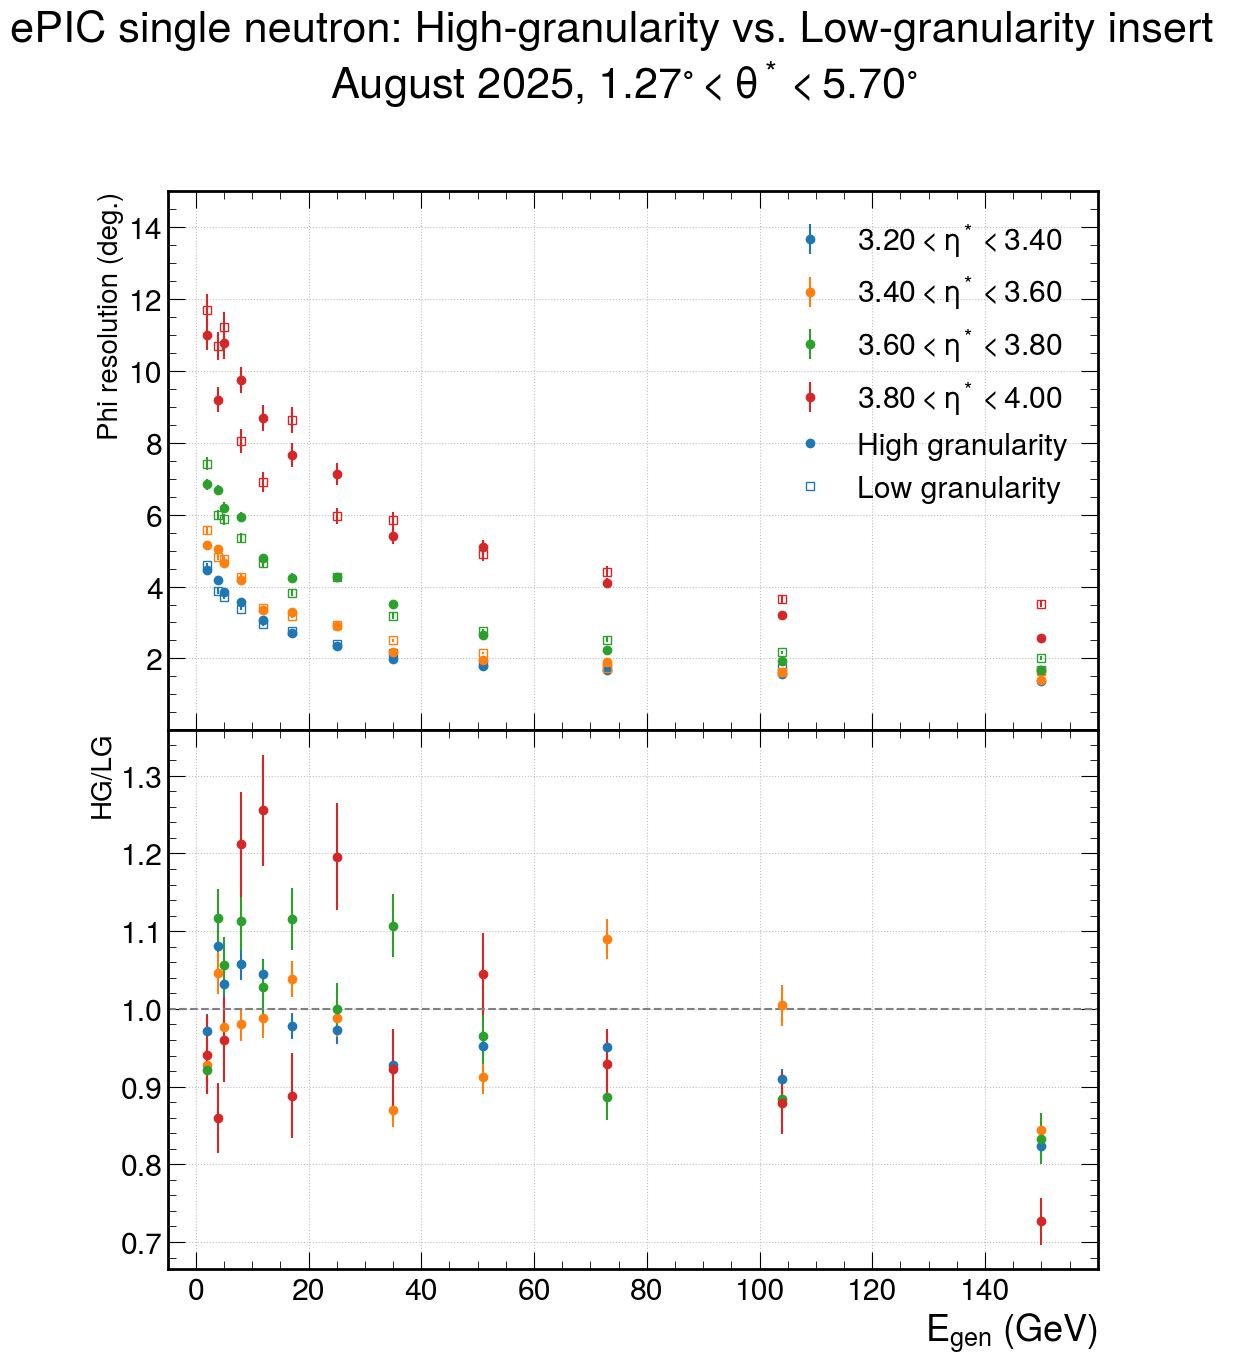

In [14]:
fig = plt.figure(figsize=(12, 14))
fig.set_facecolor('w')
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True, sharey=False)

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    color = color_list[i]

    # High granularity
    hg_truth_energy = high_granularity_dict["eta_truth_energies"][i]
    hg_energy_mask = hg_truth_energy >= lower_energy_lim
    hg_phi_resolution = np.array(high_granularity_dict["eta_phi_resolutions"][i][0])*180/np.pi
    hg_phi_resolution_error = np.array(high_granularity_dict["eta_phi_resolutions"][i][1])*180/np.pi
    axs[0].errorbar(
        hg_truth_energy[hg_energy_mask],
        np.asarray(hg_phi_resolution)[hg_energy_mask],
        yerr=np.asarray(hg_phi_resolution_error)[hg_energy_mask],
        marker='o',
        color=color,
        linestyle='none',
        label=f"${eta_range[0]:.2f}<\\eta^*<{eta_range[1]:.2f}$"
    )

    # Low granularity
    lg_truth_energy = low_granularity_dict["eta_truth_energies"][i]
    lg_energy_mask = lg_truth_energy >= lower_energy_lim
    lg_phi_resolution = np.array(low_granularity_dict["eta_phi_resolutions"][i][0])*180/np.pi
    lg_phi_resolution_error = np.array(low_granularity_dict["eta_phi_resolutions"][i][1])*180/np.pi
    axs[0].errorbar(
        lg_truth_energy[lg_energy_mask],
        np.asarray(lg_phi_resolution)[lg_energy_mask],
        yerr=np.asarray(lg_phi_resolution_error)[lg_energy_mask],
        marker='s',
        linestyle='none',
        color=color,
        markerfacecolor='none'
    )
    
    ratio, ratio_error = DivideWithErrors(np.array(hg_phi_resolution), np.array(hg_phi_resolution_error), np.array(lg_phi_resolution), np.array(lg_phi_resolution_error))
    
    axs[1].errorbar(
        lg_truth_energy[lg_energy_mask],
        np.asarray(ratio)[lg_energy_mask],
        yerr=np.asarray(ratio_error)[lg_energy_mask],
        marker='o',
        color=color,
        linestyle='none',
    )

high_gran_handle = mlines.Line2D([], [], color=color_list[0], marker='o',
                                 linestyle='none', label='High-granularity')
low_gran_handle  = mlines.Line2D([], [], color=color_list[0], marker='s',
                                 markerfacecolor='none', linestyle='none',
                                 label='Low-granularity')

handles, labels = axs[0].get_legend_handles_labels()
handles.extend([high_gran_handle, low_gran_handle])
labels.extend(['High granularity', 'Low granularity'])
    
axs[0].set_ylabel("Phi resolution (deg.)",  fontsize=20)
axs[0].set_ylim(0.01, 15)
axs[0].set_xlim(-4.99, 159.99)
axs[0].legend(handles, labels, frameon=False)
axs[1].set_ylabel("HG/LG",  fontsize=20)
axs[1].set_xlabel("$E_{gen}$ (GeV)")
axs[0].grid()
axs[1].grid()
axs[1].hlines(y=1, xmin=-4.99, xmax=159.99, color='gray', linestyle='dashed')
if use_eta_mask:
    plt.suptitle(plot_title, y=1.01)
else:
    plt.suptitle(plot_title, y=.99)